In [ ]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import process_probe as pp
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *
import optuna # Import Optuna
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import importlib
import IntegratedGradient

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('units_info.csv')
print(df.head())

Index(['unit_id', 'session_id', 'genotype', 'optotagged', 'cluster_id', 'pyr',
       'sst', 'vip', 'coupling_index', 'normalized_depth', 'stLFP',
       'mean_stPR', 'cv2', 'acg_tau_rise', 'acg_tau_decay', 'acg_c', 'acg_d',
       'firingRateISI', 'thetaModulationIndex', 'burstIndex_Royer2012',
       'burstIndex_Mizuseki2012', 'num_conn_e_to_e', 'num_conn_e_to_i',
       'num_conn_e_from_e', 'num_conn_i_from_e', 'num_conn_i_to_e',
       'num_conn_i_to_i', 'num_conn_e_from_i', 'num_conn_i_from_i'],
      dtype='object')


In [2]:
# Session obj contains stimulus, channel, and unit information
output_dir  = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022'
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)

# hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
num_epochs = 15 # 
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
batch_size = 32

In [3]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
# spikes_obj.convolve_with_gaussian() # skip convolution
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

100%|██████████| 8/8 [03:12<00:00, 24.02s/it]


In [4]:
chani = 5 # deep layer
bandi = 0 # broadband

# X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
#                                                       seqlength, prediction_lag=0, test_size=0.2, random_state=42)

# train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

In [5]:
def objective(trial):
    """Optuna objective function to minimize validation loss."""

    # --- Suggest Hyperparameters ---
    embedding_dim = trial.suggest_categorical("embedding_dim", [32, 64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 1, 6)
    seqlength = trial.suggest_categorical("seqlength", np.arange(25, 500, 25).tolist())
    

    # Ensure num_heads is a divisor of embedding_dim
    possible_heads = [h for h in [1, 2, 4, 8, 16] if embedding_dim % h == 0]
    if not possible_heads: # Fallback if no divisors found (shouldn't happen with choices above)
         possible_heads = [1]
    num_heads = trial.suggest_categorical("num_heads", possible_heads)

    dropout = trial.suggest_float("dropout", 0.05, 0.5, step=0.05)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # --- Instantiate Model ---
    model = models.SpikingTransformer(
        input_size=input_size, # Use global num_neurons
        seqlength=seqlength,    # Use global seqlength
        embedding_dim=embedding_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    criterion = torch.nn.MSELoss()
    
    # --- Train and Evaluate ---
    processor = models.process_model(model, criterion, device)

    # Use val_dataloader as the 'test_dataloader' for evaluation within train
    # Train for a fixed number of epochs for hyperparameter comparison
    # You might need more epochs in final training
    num_optuna_epochs = 10 # Adjust as needed - balance speed and convergence
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

    train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

    transformer_train_loss, transformer_test_loss = processor.train(train_dataloader,
                                        test_dataloader , num_optuna_epochs, lr=lr, weight_decay=weight_decay)

    # --- Return the metric to minimize (e.g., final validation loss) ---
    final_val_loss = transformer_test_loss[-1]

    # --- Optional: Optuna Pruning (Stop unpromising trials early) ---
    trial.report(final_val_loss, step=num_optuna_epochs - 1)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return final_val_loss # Optuna minimizes this value

In [6]:
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)

study_name = "spiking-transformer-optimization-fixed-bs" # Updated name
storage_name = output_dir_models / f"{study_name}.db"

study = optuna.create_study(
    direction="minimize",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner()
)

print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=20)


[I 2025-05-13 11:41:53,157] A new study created in memory with name: no-name-39992335-e15d-443f-acb8-b1abd331229f


Sampler is TPESampler


[I 2025-05-13 11:42:20,151] Trial 0 finished with value: 0.9021572004193845 and parameters: {'embedding_dim': 64, 'num_layers': 4, 'seqlength': 250, 'num_heads': 1, 'dropout': 0.15000000000000002, 'lr': 0.003859771305758329, 'weight_decay': 4.972182005023251e-05}. Best is trial 0 with value: 0.9021572004193845.
[I 2025-05-13 11:43:00,402] Trial 1 finished with value: 0.6770289937655131 and parameters: {'embedding_dim': 64, 'num_layers': 3, 'seqlength': 275, 'num_heads': 16, 'dropout': 0.25, 'lr': 0.0023801271832957533, 'weight_decay': 0.00010887692680860521}. Best is trial 1 with value: 0.6770289937655131.
[I 2025-05-13 11:43:49,727] Trial 2 finished with value: 0.6767389894577495 and parameters: {'embedding_dim': 64, 'num_layers': 6, 'seqlength': 100, 'num_heads': 8, 'dropout': 0.35000000000000003, 'lr': 5.876200260840643e-05, 'weight_decay': 8.667380850265388e-05}. Best is trial 2 with value: 0.6767389894577495.
[I 2025-05-13 11:44:28,342] Trial 3 finished with value: 0.3059635709608

In [ ]:
# Print the best hyperparameters 
best_params   = study.best_params
best_accuracy = study.best_value
print("Best Hyperparameters: ", best_params)
print("Best Acc: ", best_accuracy)

Best Hyperparameters:  {'embedding_dim': 32, 'num_layers': 2, 'seqlength': 50, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.00040429934834439863, 'weight_decay': 6.689911550230387e-06}
Best Acc:  0.3059635709608551


In [5]:
embedding_dim = 32
num_layers = 2
seqlength = 50 
num_heads = 2
dropout = 0.1
lr = 0.0004
weight_decay = 6.7e-06

In [6]:
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = embedding_dim,
                                                                   num_heads = num_heads, 
                                                                   num_layers = num_layers,
                                                                   dropout=dropout), criterion, device)

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                    seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)


transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer,
                                        lr = lr, weight_decay=weight_decay)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.3026
transformer  test loss:  0.3317


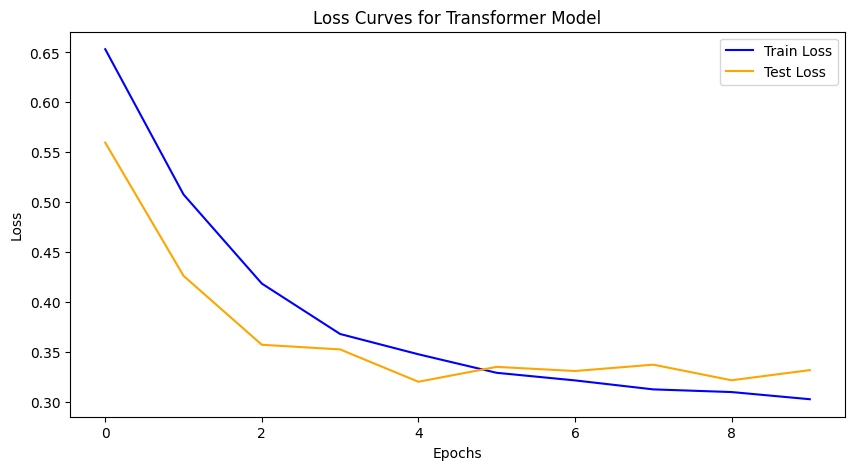

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(transformer_train_loss, label='Train Loss', color='blue')
ax.plot(transformer_test_loss, label='Test Loss', color='orange')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves for Transformer Model')
ax.legend()
plt.show()


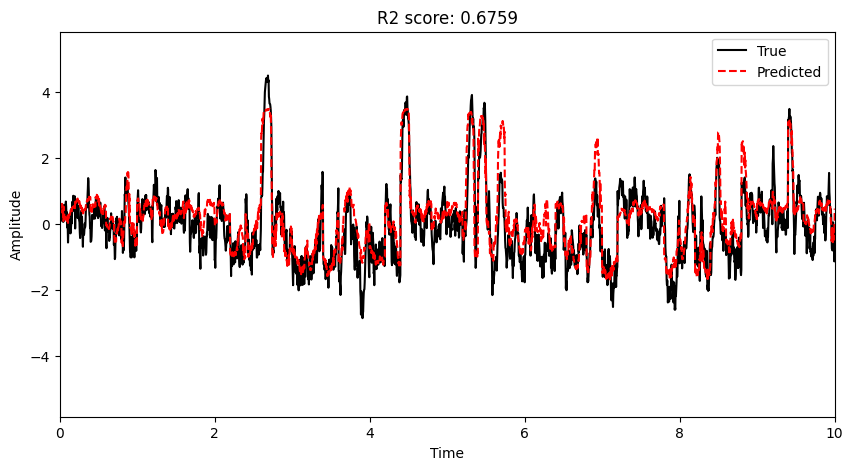

In [8]:
test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
plt.show()



In [237]:
lossesTrain, lossesTest = (np.zeros((len(lfp_obj.channels), num_epochs, len(bands)+1)) for _ in range(2))
R2_train, R2_test       = (np.zeros((len(lfp_obj.channels), len(bands)+1)) for _ in range(2))

# initialize dictionary to store trained models 
all_models = {}

for bandi in range(len(bands)+1):
    sys.stdout.write('\r' + 'Working on band ' + str(bandi + 1) + ' out of ' + str(len(bands)+1) + '\n')
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,:,bandi], 
                                                      seqlength, test_size=0.2, random_state=42)

    for chani in range(len(lfp_obj.channels)):
        sys.stdout.write('\t' + 'Training model for channel ' + str(chani+1) + ' out of ' + str(lfp_obj.lfpMat.shape[1]) + '\n')
        
        train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train[:,:,chani], y_test[:,:,chani], batch_size , device)
        
        model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = embedding_dim,
                                                                   num_heads = num_heads, 
                                                                   num_layers = num_layers,
                                                                   dropout=dropout), criterion, device)
        
        train_loss, test_loss = model.train(train_dataloader,
                                        test_dataloader , num_epochs)
        
        yHat = model.evaluate(test_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_test[chani, bandi] = r2_score(test_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        yHat = model.evaluate(train_dataloader.dataset.tensors[0]).cpu().numpy()
        R2_train[chani, bandi] = r2_score(train_dataloader.dataset.tensors[1].cpu().numpy().reshape(-1,1), yHat)
        
        lossesTrain[chani,:, bandi] = train_loss
        lossesTest[chani,:, bandi] = test_loss
        
        all_models[chani, bandi] = model


Working on band 1 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model for channel 4 out of 20
	Training model for channel 5 out of 20
	Training model for channel 6 out of 20
	Training model for channel 7 out of 20
	Training model for channel 8 out of 20
	Training model for channel 9 out of 20
	Training model for channel 10 out of 20
	Training model for channel 11 out of 20
	Training model for channel 12 out of 20
	Training model for channel 13 out of 20
	Training model for channel 14 out of 20
	Training model for channel 15 out of 20
	Training model for channel 16 out of 20
	Training model for channel 17 out of 20
	Training model for channel 18 out of 20
	Training model for channel 19 out of 20
	Training model for channel 20 out of 20
Working on band 2 out of 9
	Training model for channel 1 out of 20
	Training model for channel 2 out of 20
	Training model for channel 3 out of 20
	Training model

In [239]:
# save the models 
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)
os.makedirs(output_dir_models, exist_ok=True)

for idx in range(len(all_models.keys())):
    chan = list(all_models.keys())[idx][0]
    band = list(all_models.keys())[idx][1]
    filename = output_dir_models / f'transformer_model_chan{chan}_band{band}.pt'
    torch.save(all_models[chan, band].model.state_dict(), filename)

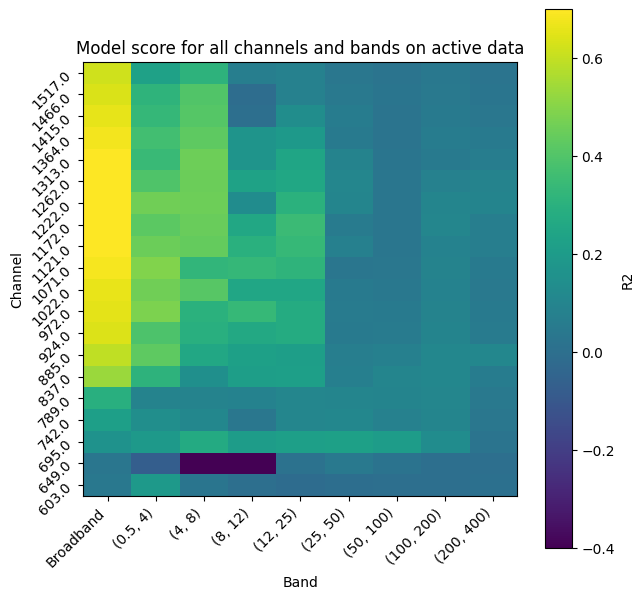

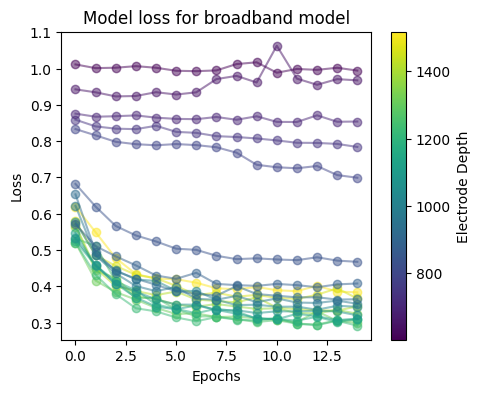

In [238]:
plot_r2(R2_test, lfp_obj.channels, bands)
plot_all_channel_loss(lfp_obj.channels, bands, 0, lossesTest)

In [ ]:
attr_dur = 720
X_attr = torch.tensor(spikes_obj.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)

ig = IntegratedGradient(transformer_model.model.train().to(device), method='last time point', seqlength=seqlength) 
attrs = ig.run(X_attr, baselines = 0, n_steps = 50)

100%|██████████| 3600/3600 [17:57<00:00,  3.34it/s]


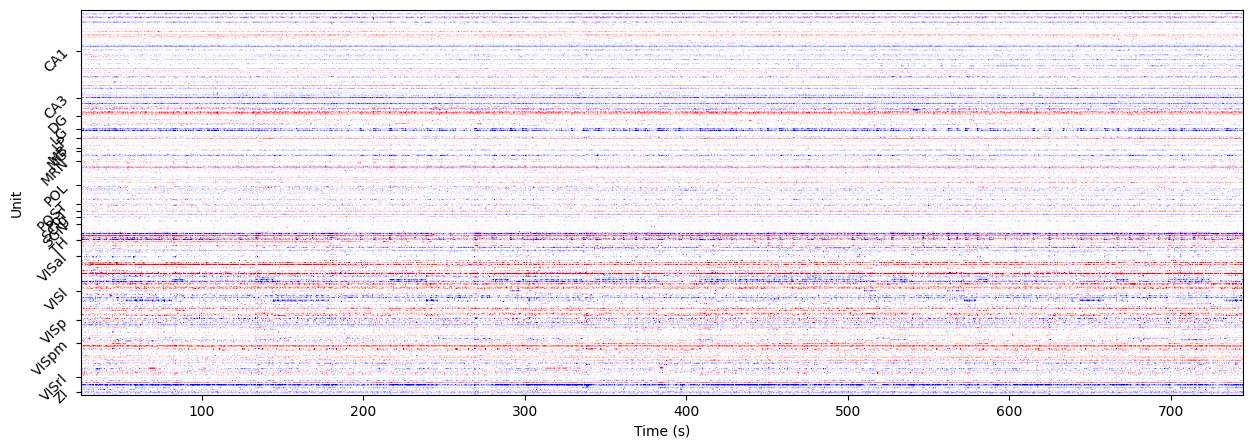

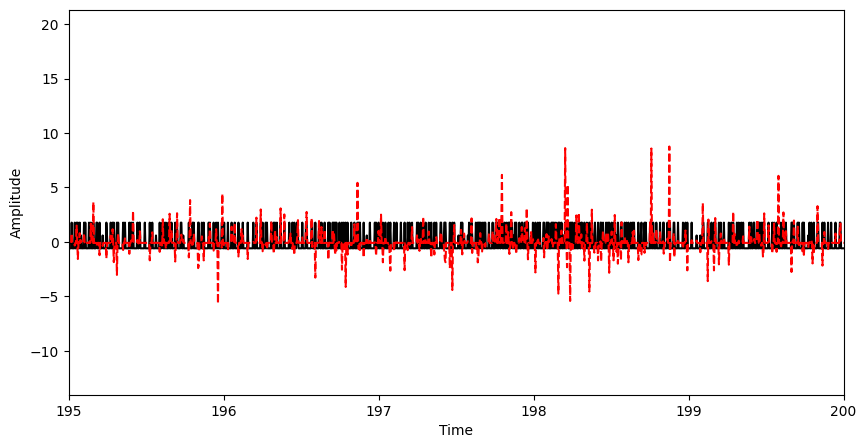

In [ ]:
normalized_attrs = attrs.cpu().numpy() / X_attr.cpu().numpy()
normalized_attrs[np.isnan(normalized_attrs)] = 0
mean_attr = np.mean(normalized_attrs, axis=0)

plot_attr_matrix(normalized_attrs, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0] + attr_dur])

win = [170, 175]
neuron = 353     # Example neuron index to plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], 
           zscore(spikes_obj.spkMat[:int(attr_dur/bin_size),neuron]), 'k', label='firing rate')
ax.plot(spikes_obj.timestamps[:int(attr_dur/bin_size)],
              zscore(attrs[:,neuron].cpu().numpy()), '--r', label='attribution score')
ax.set_xlim([spikes_obj.timestamps[0]+win[0], spikes_obj.timestamps[0]+win[1]])
# ax.set_ylim([-10, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
plt.show()

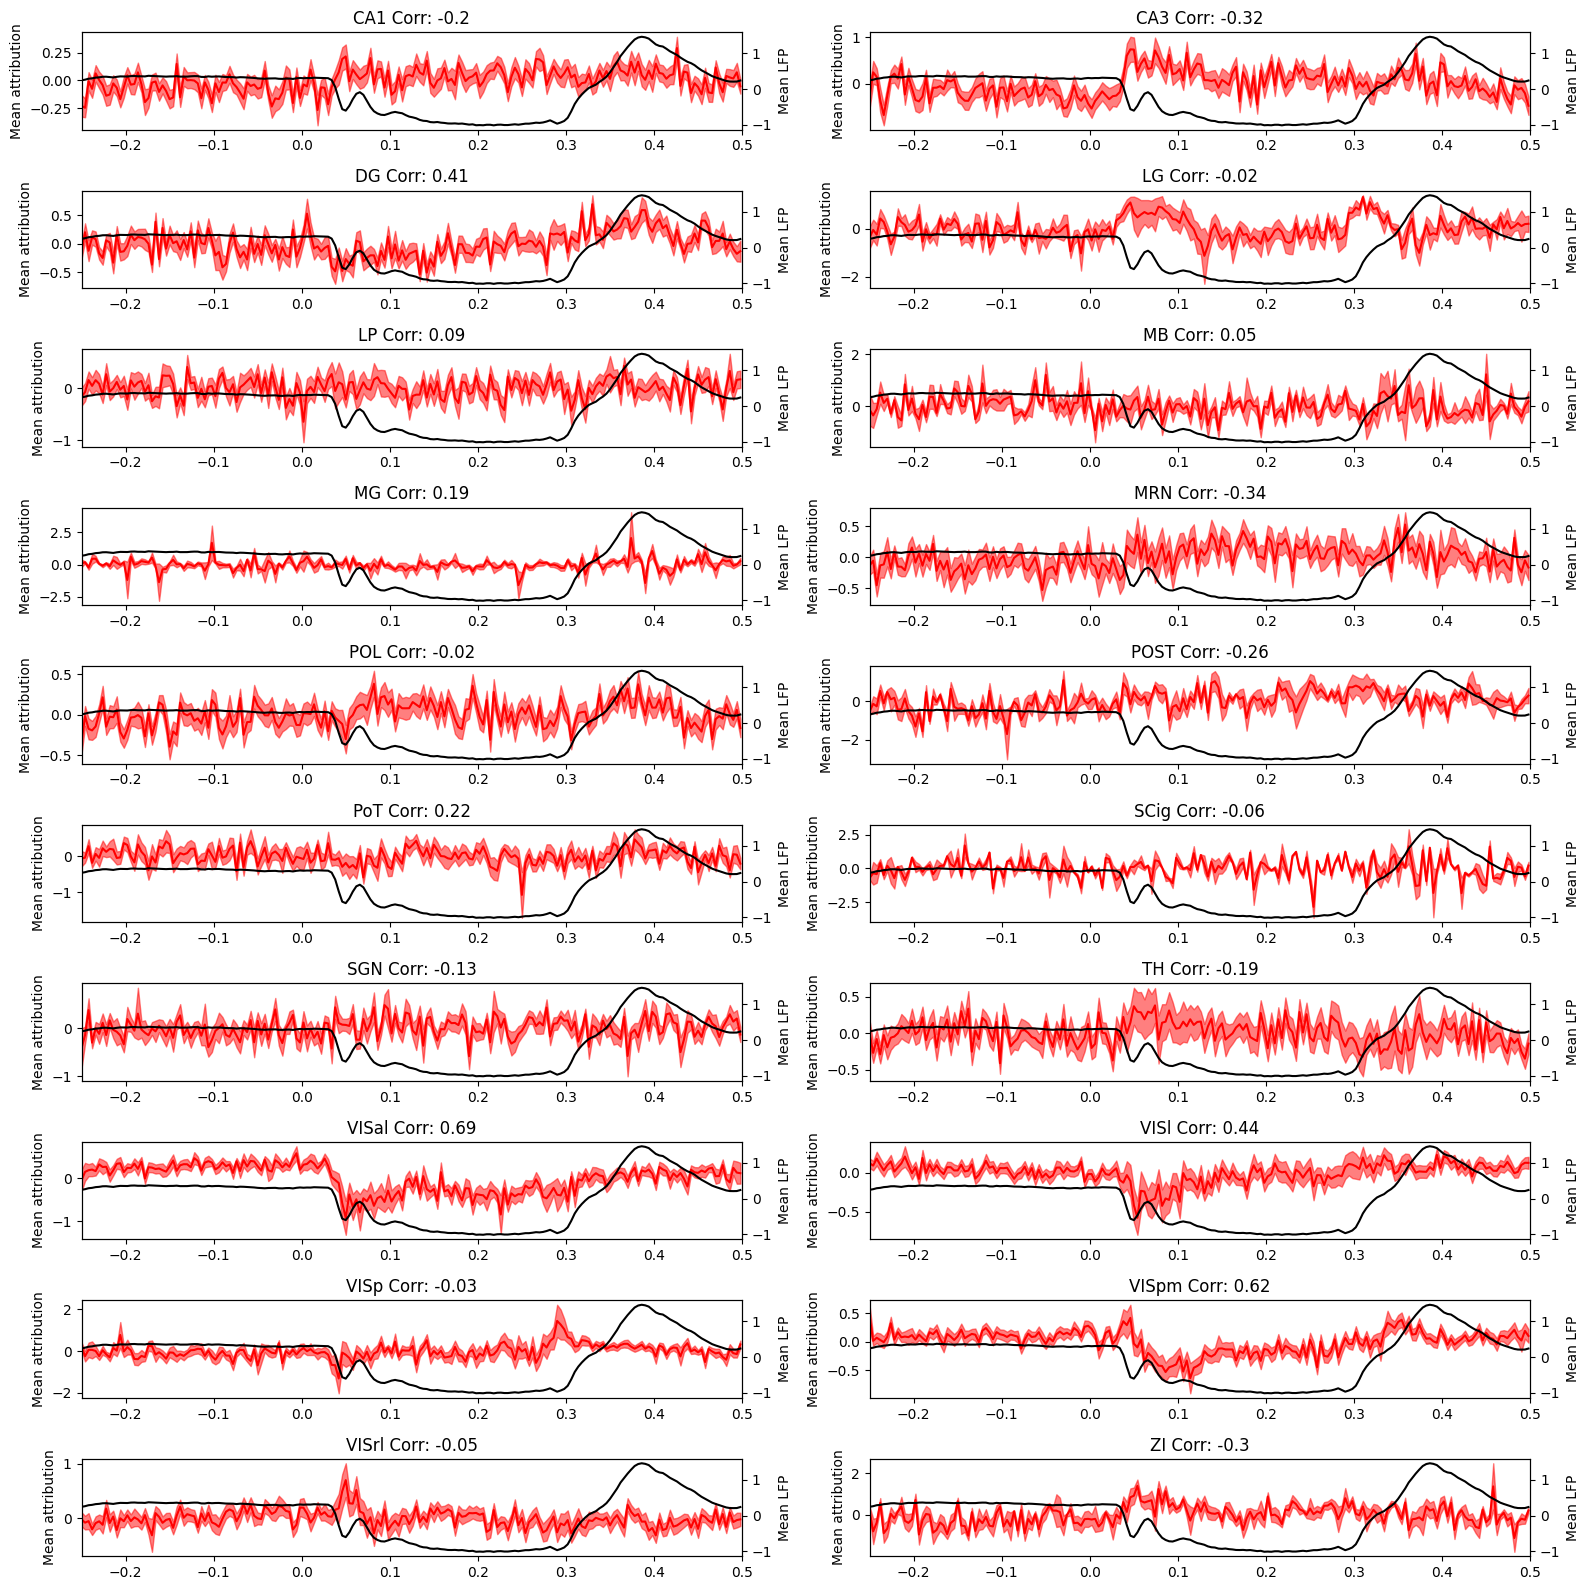

In [16]:
# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
attr_snippets, lfp_snippets, t = plot_peri_stim_attr(attrs.cpu().numpy() , lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0], session_obj,
                    spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5])

In [ ]:
# for each neuron, calculate the distance from the LFP channel
lfp_coords = [lfp_obj.channels['anterior_posterior_ccf_coordinate'].iloc[chani], 
                lfp_obj.channels['dorsal_ventral_ccf_coordinate'].iloc[chani], 
                lfp_obj.channels['left_right_ccf_coordinate'].iloc[chani]]
dist_from_lfp = []
for i in range(len(session_obj.units)):
    dist = np.sqrt((session_obj.units['anterior_posterior_ccf_coordinate'].iloc[i] - lfp_coords[0])**2 +
                   (session_obj.units['dorsal_ventral_ccf_coordinate'].iloc[i] - lfp_coords[1])**2 +
                   (session_obj.units['left_right_ccf_coordinate'].iloc[i] - lfp_coords[2])**2)
    dist_from_lfp.append(dist)
dist_from_lfp = np.array(dist_from_lfp)

In [408]:
merged_df = pd.merge(
    session_obj.units,
    df.rename(columns={'unit_id': 'id'}).set_index('id'),
    left_on='id',
    right_index=True
)
print(merged_df.columns)

Index(['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cluster_id_x',
       'cumulative_drift', 'd_prime', 'firing_rate', 'isi_violations',
       'isolation_distance', 'l_ratio', 'local_index', 'max_drift',
       'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio',
       'quality', 'recovery_slope', 'repolarization_slope', 'silhouette_score',
       'snr', 'spread', 'velocity_above', 'velocity_below',
       'waveform_duration', 'anterior_posterior_ccf_coordinate',
       'dorsal_ventral_ccf_coordinate', 'filtering',
       'left_right_ccf_coordinate', 'probe_channel_number',
       'probe_horizontal_position', 'probe_id', 'probe_vertical_position',
       'structure_acronym', 'session_id', 'genotype', 'optotagged',
       'cluster_id_y', 'pyr', 'sst', 'vip', 'coupling_index',
       'normalized_depth', 'stLFP', 'mean_stPR', 'cv2', 'acg_tau_rise',
       'acg_tau_decay', 'acg_c', 'acg_d', 'firingRateISI',
       'thetaModulationIndex', 'burstIndex_Royer2012',
       'b

In [457]:
hierarchy_score = {'LG' : -0.515,
                   'VISp' : -0.357,
                   'VISl' : -0.093,
                   'VISrl' : -0.059,
                   'LP' : 0.105,
                   'VISal' : 0.152,
                   'VISpm' : 0.327,
                   'VISam' : 0.441}

metrics = ['firing_rate','coupling_index', 'acg_tau_rise', 'acg_tau_decay','amplitude','stLFP', 'mean_stPR',
           'normalized_depth','cv2','firingRateISI','thetaModulationIndex','burstIndex_Royer2012','burstIndex_Mizuseki2012']

attr_df = pd.DataFrame({
    'attribution_score': np.abs(mean_attr),
    'structure_acronym': session_obj.units['structure_acronym'],
    'distance_from_lfp': dist_from_lfp
})
for metric in metrics:
    attr_df[metric] = merged_df[metric].values
attr_df['hierarchy_score'] = attr_df['structure_acronym'].map(hierarchy_score)
# set inf values to NaN
attr_df.replace([np.inf, -np.inf], np.nan, inplace=True)

attr_df.head()

,attribution_score,structure_acronym,distance_from_lfp,firing_rate,coupling_index,acg_tau_rise,acg_tau_decay,amplitude,stLFP,mean_stPR,normalized_depth,cv2,firingRateISI,thetaModulationIndex,burstIndex_Royer2012,burstIndex_Mizuseki2012,hierarchy_score
id,,,,,,,,,,,,,,,,,
1049374910,2.007536e-03,VISpm,1306.643792,8.577549,0.722577,9.463403,7.177660,334.314240,-1.274261,1.114745,0.674419,0.570249,14.895818,0.038829,0.023038,0.004456,0.327
1049374988,9.923875e-07,VISpm,1405.121347,0.547925,0.432222,9.950514,14.127059,274.415115,0.304777,0.430560,0.372093,0.666279,11.162857,-0.026786,0.039842,0.002169,0.327
1049373561,8.065181e-03,POL,2722.999266,16.918544,NaN,14.557467,21.248613,488.096700,NaN,NaN,NaN,0.685502,23.474318,0.011154,0.277931,0.035044,NaN
1049373556,3.414240e-03,POL,2722.999266,16.652535,NaN,23.092214,58.264320,310.195860,NaN,NaN,NaN,0.627994,21.660779,0.005001,0.261668,0.028601,NaN
1049373138,1.301108e-02,PoT,3097.552744,19.336021,NaN,4.704684,5.989799,168.996555,NaN,NaN,NaN,0.915701,3.258764,-0.148733,0.668874,0.028902,NaN


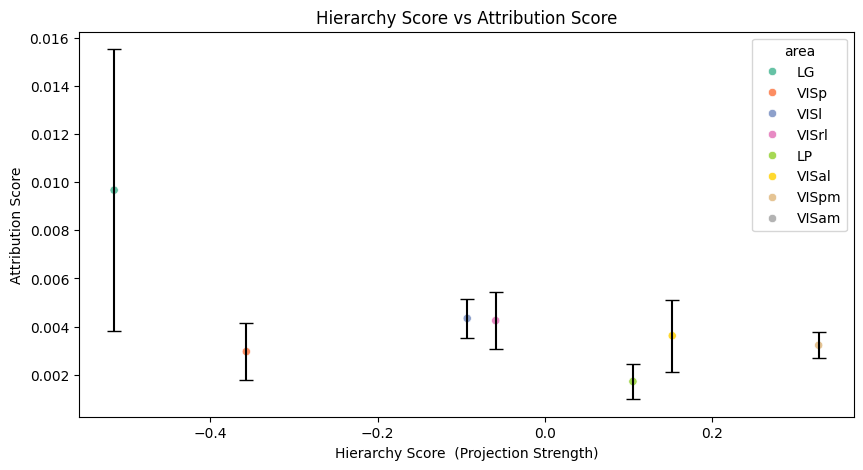

In [468]:
# for each area in hierarchy_score, calculate the average attribution score plus the standard deviation
attr_scores = {area: attr_df[attr_df['structure_acronym'] == area]['attribution_score'].mean() for area in hierarchy_score.keys()}
attr_stds   = {area: attr_df[attr_df['structure_acronym'] == area]['attribution_score'].std() for area in hierarchy_score.keys()}

# create a dataframe with the projection strength and the attribution score
hierarchy_score_df = pd.DataFrame({
    'area': list(hierarchy_score.keys()),
    'hierarchy_score': list(hierarchy_score.values()),
    'attribution_score': [attr_scores[area] for area in hierarchy_score.keys()],
    'attribution_std': [attr_stds[area] for area in hierarchy_score.keys()]
})

num_cells = [len(session_obj.units[session_obj.units['structure_acronym'] == area]) for area in hierarchy_score.keys()]

# plot the projection strength against the attribution score
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.scatterplot(data=hierarchy_score_df, x='hierarchy_score', y='attribution_score', ax=ax, hue='area', palette='Set2')
ax.set_xlabel('Hierarchy Score  (Projection Strength)')                             
ax.set_ylabel('Attribution Score')
ax.set_title('Hierarchy Score vs Attribution Score')
# Add error bars for standard deviation
for i in range(len(hierarchy_score_df)):
    ax.errorbar(hierarchy_score_df['hierarchy_score'].iloc[i], hierarchy_score_df['attribution_score'].iloc[i],
                yerr=hierarchy_score_df['attribution_std'].iloc[i] / np.sqrt(num_cells[i]), fmt='none', capsize=5, color='black')
plt.show()


In [404]:
area_list = pd.read_csv('area_list.csv', header=None).values.tolist()
area_list = [x[0] for x in area_list]  # Convert to a flat list
thal_list = pd.read_csv('thal_list.csv', header=None).values.tolist()
thal_list = [x[0] for x in thal_list]  # Convert to a flat list
thal_list[thal_list=='LGd'] = 'LG'  # Replace LGd with LG

conn_cxcx = pd.read_csv('conn_cxcx.csv', header=None).values
conn_thcx = pd.read_csv('conn_thcx.csv', header=None).values

In [415]:
area_list_idx = {area: i for i, area in enumerate(area_list) if area in attr_df['structure_acronym'].unique()}
thal_list_idx = {area: i for i, area in enumerate(thal_list) if area in attr_df['structure_acronym'].unique()}
proj_strength_ctx  = {area: conn_cxcx[0,area_list_idx[area]] for area in area_list_idx.keys() if area != 'VISp'}
proj_strength_thal = {area: conn_thcx[0,thal_list_idx[area]] for area in thal_list_idx.keys()}
proj_strength_combined = {**proj_strength_ctx, **proj_strength_thal} 
proj_strength_combined

{'VISl': 0.0006050728736574008,
 'VISrl': 0.0003475302637651727,
 'VISal': 0.00030779942574230994,
 'VISpm': 0.0004378486643196839,
 'LG': 1.55239817559095e-05,
 'MG': 0.00016929510750580477,
 'LP': 0.0010579280851421438,
 'POL': 0.00023264489375657017,
 'SGN': 0.0003739867576271255}

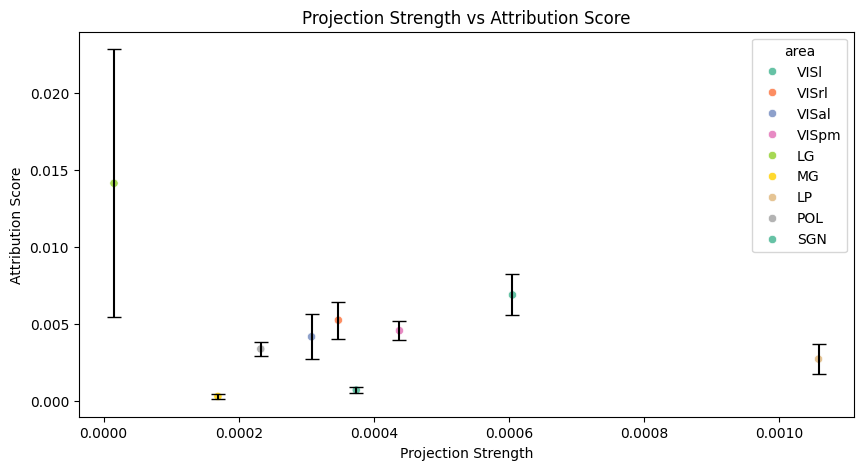

In [ ]:
# for each area in proj_strength_combined, calculate the average attribution score plus the standard deviation
attr_scores = {area: attr_df[attr_df['structure_acronym'] == area]['attribution_score'].mean() for area in proj_strength_combined.keys()}
attr_stds   = {area: attr_df[attr_df['structure_acronym'] == area]['attribution_score'].std() for area in proj_strength_combined.keys()}

# create a dataframe with the projection strength and the attribution score
proj_strength_df = pd.DataFrame({
    'area': list(proj_strength_combined.keys()),
    'projection_strength': list(proj_strength_combined.values()),
    'attribution_score': [attr_scores[area] for area in proj_strength_combined.keys()],
    'attribution_std': [attr_stds[area] for area in proj_strength_combined.keys()]
})

num_cells = [len(session_obj.units[session_obj.units['structure_acronym'] == area]) for area in proj_strength_combined.keys()]

# plot the projection strength against the attribution score
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.scatterplot(data=proj_strength_df, x='projection_strength', y='attribution_score', ax=ax, hue='area', palette='Set2')
ax.set_xlabel('Projection Strength')
ax.set_ylabel('Attribution Score')
ax.set_title('Projection Strength vs Attribution Score')
# Add error bars for standard deviation
for i in range(len(proj_strength_df)):
    ax.errorbar(proj_strength_df['projection_strength'].iloc[i], proj_strength_df['attribution_score'].iloc[i],
                yerr=proj_strength_df['attribution_std'].iloc[i] / np.sqrt(num_cells[i]), fmt='none', capsize=5, color='black')
plt.show()

100%|██████████| 623/623 [00:00<00:00, 1879.10it/s]


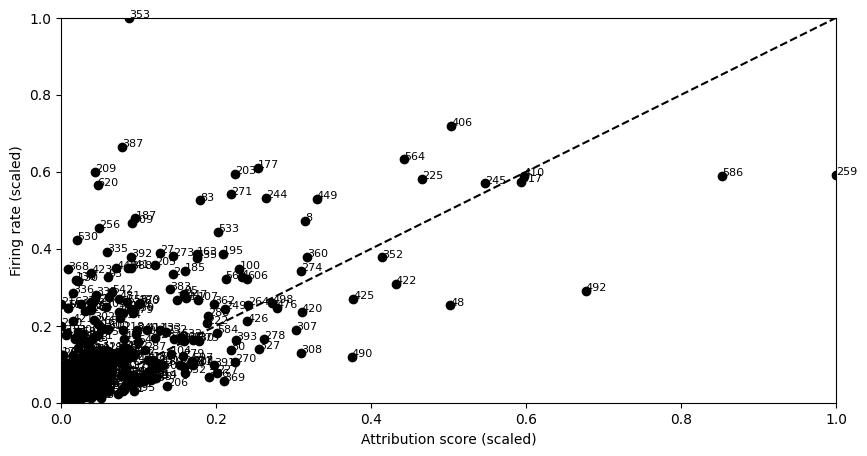

In [456]:
tmp_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=1)
tmp_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[0] + attr_dur)

fr_attr = np.sum(tmp_obj.spkMat, axis=0) / attr_dur # firing rate in Hz
fr_attr[fr_attr == 0] = 1e-10 # avoid log(0)

# import minmax scaling function
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaled_attr = scaler.fit_transform(attr_df['attribution_score'].values.reshape(-1,1))
scaled_fr   = scaler.fit_transform(fr_attr.reshape(-1,1))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# scatter plot with the neuron number next to the point
for i in range(len(scaled_attr)):
    ax.annotate(i, (scaled_attr[i], scaled_fr[i]), fontsize=8)
ax.plot(scaled_attr, scaled_fr, 'ok')
ax.plot([-1,1], [-1, 1], '--k')
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_xlabel('Attribution score (scaled)')
ax.set_ylabel('Firing rate (scaled)')
plt.show()

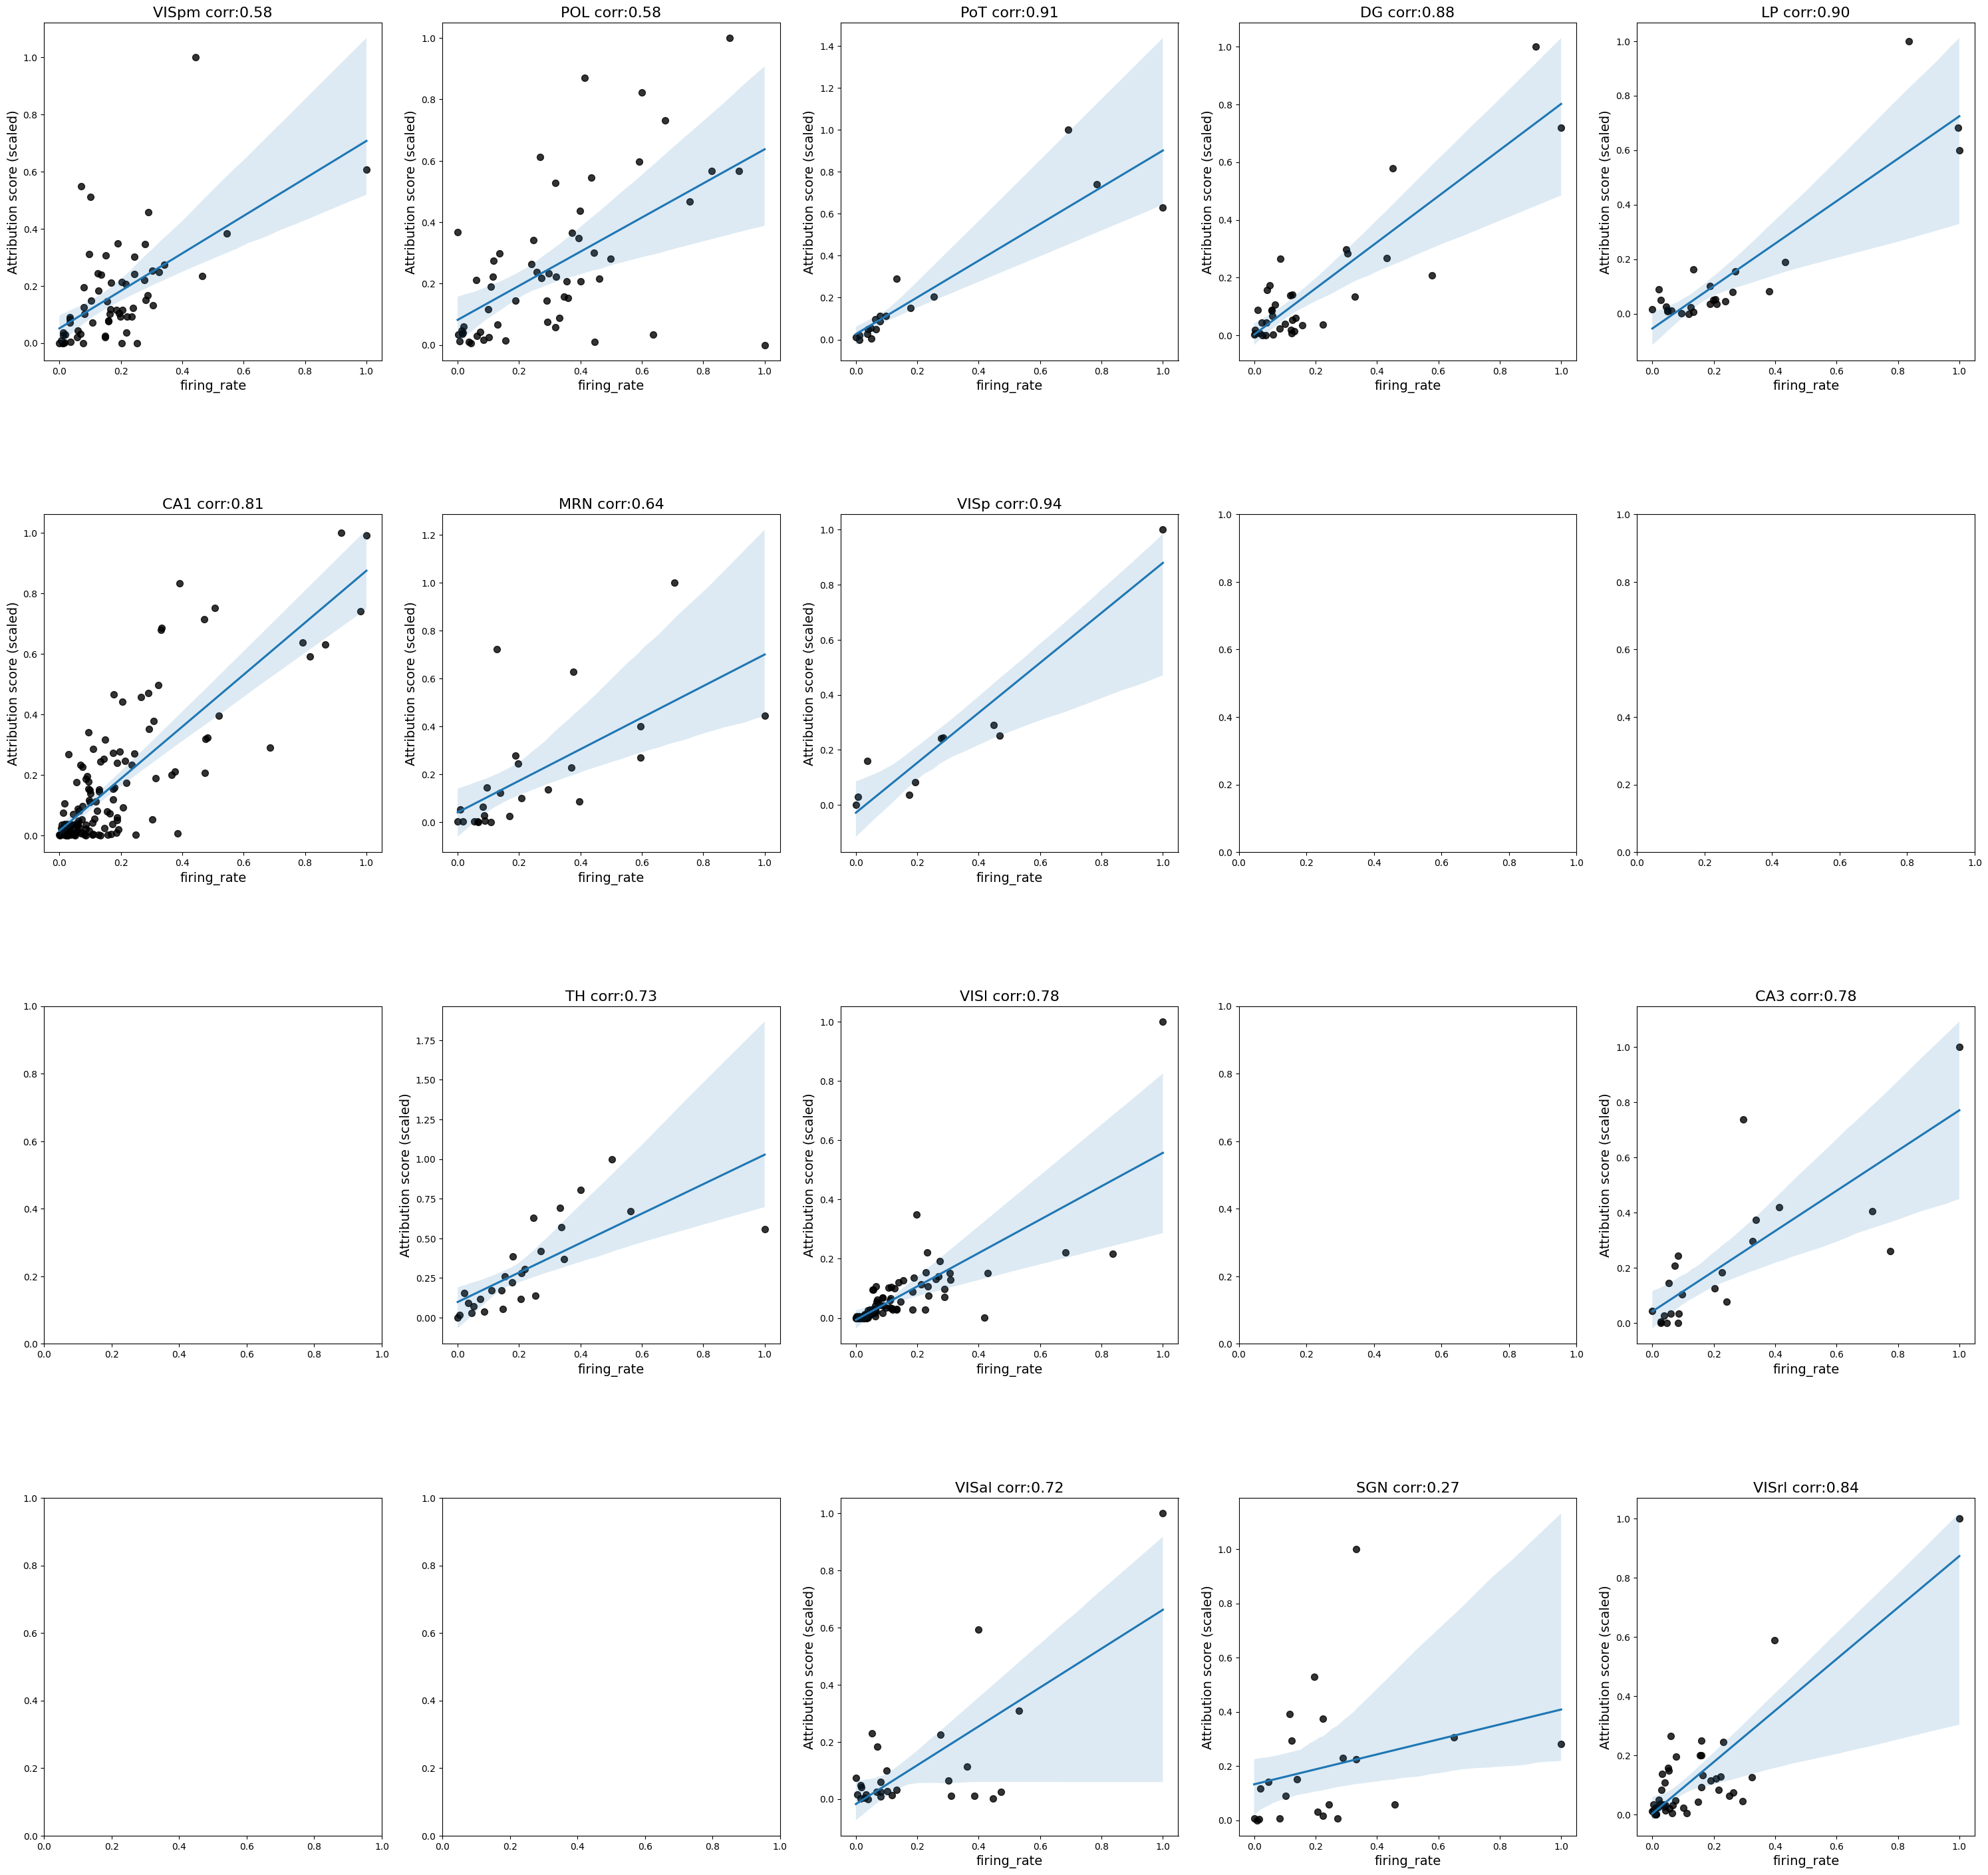

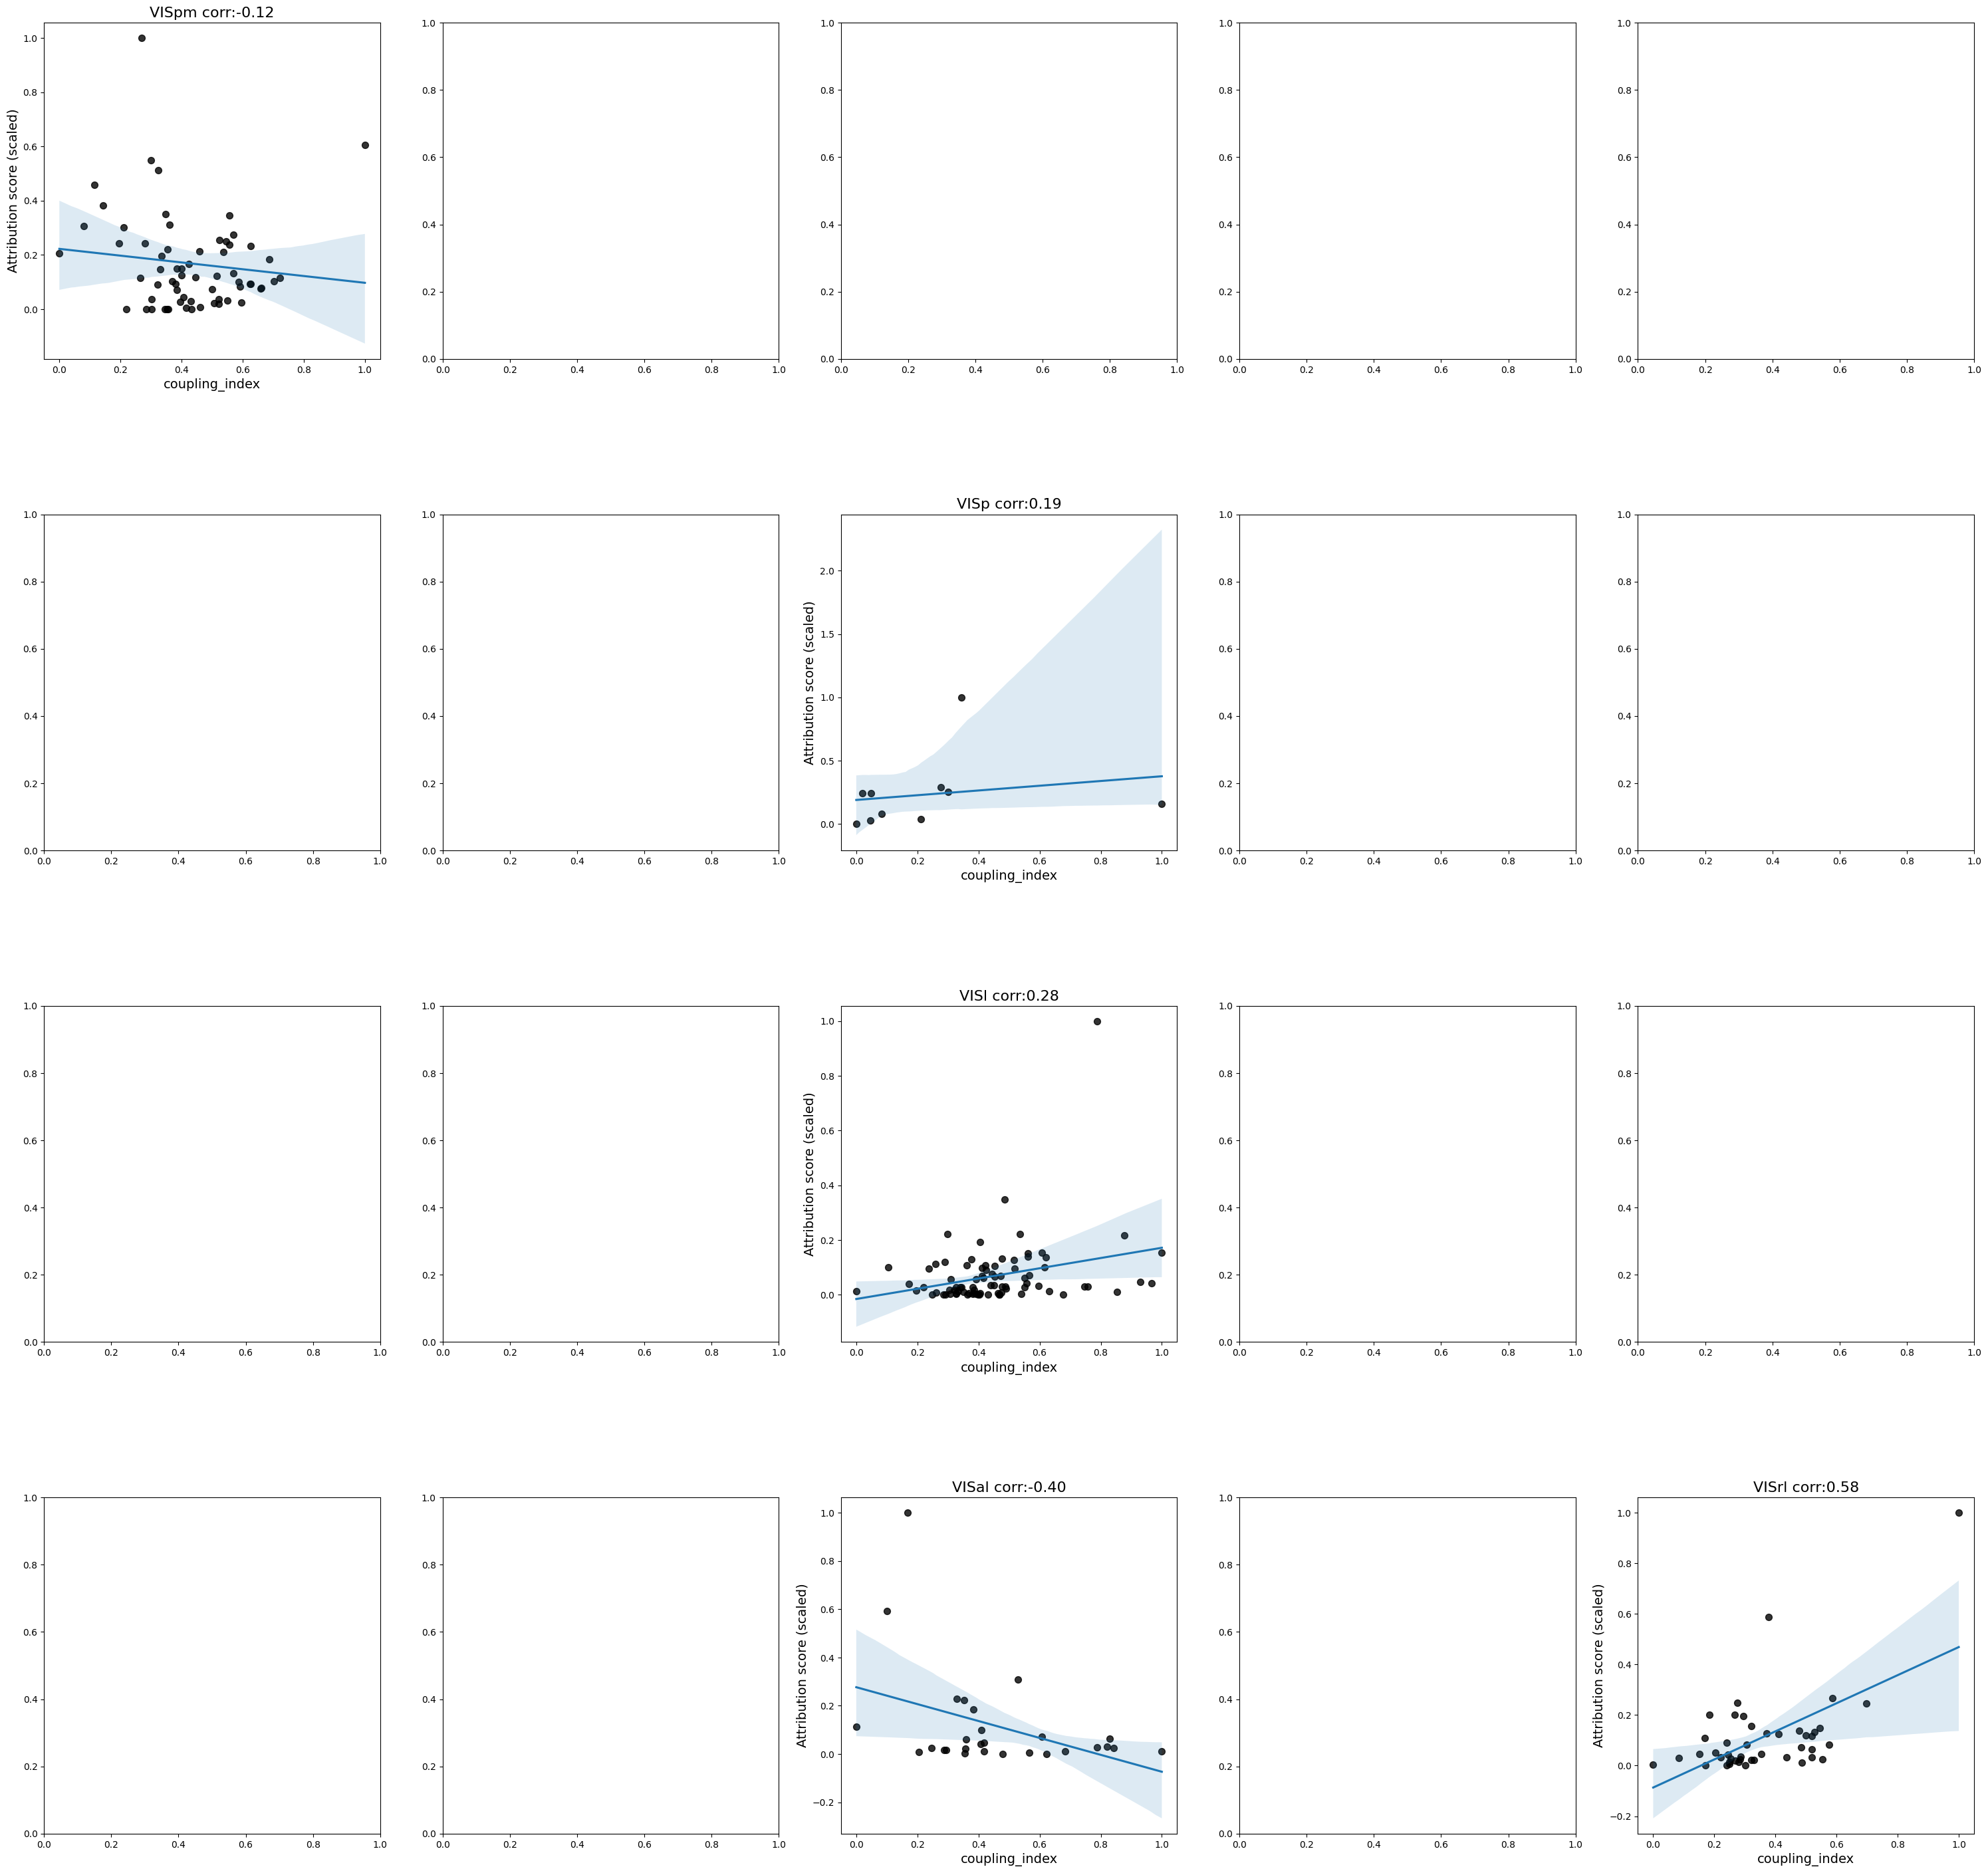

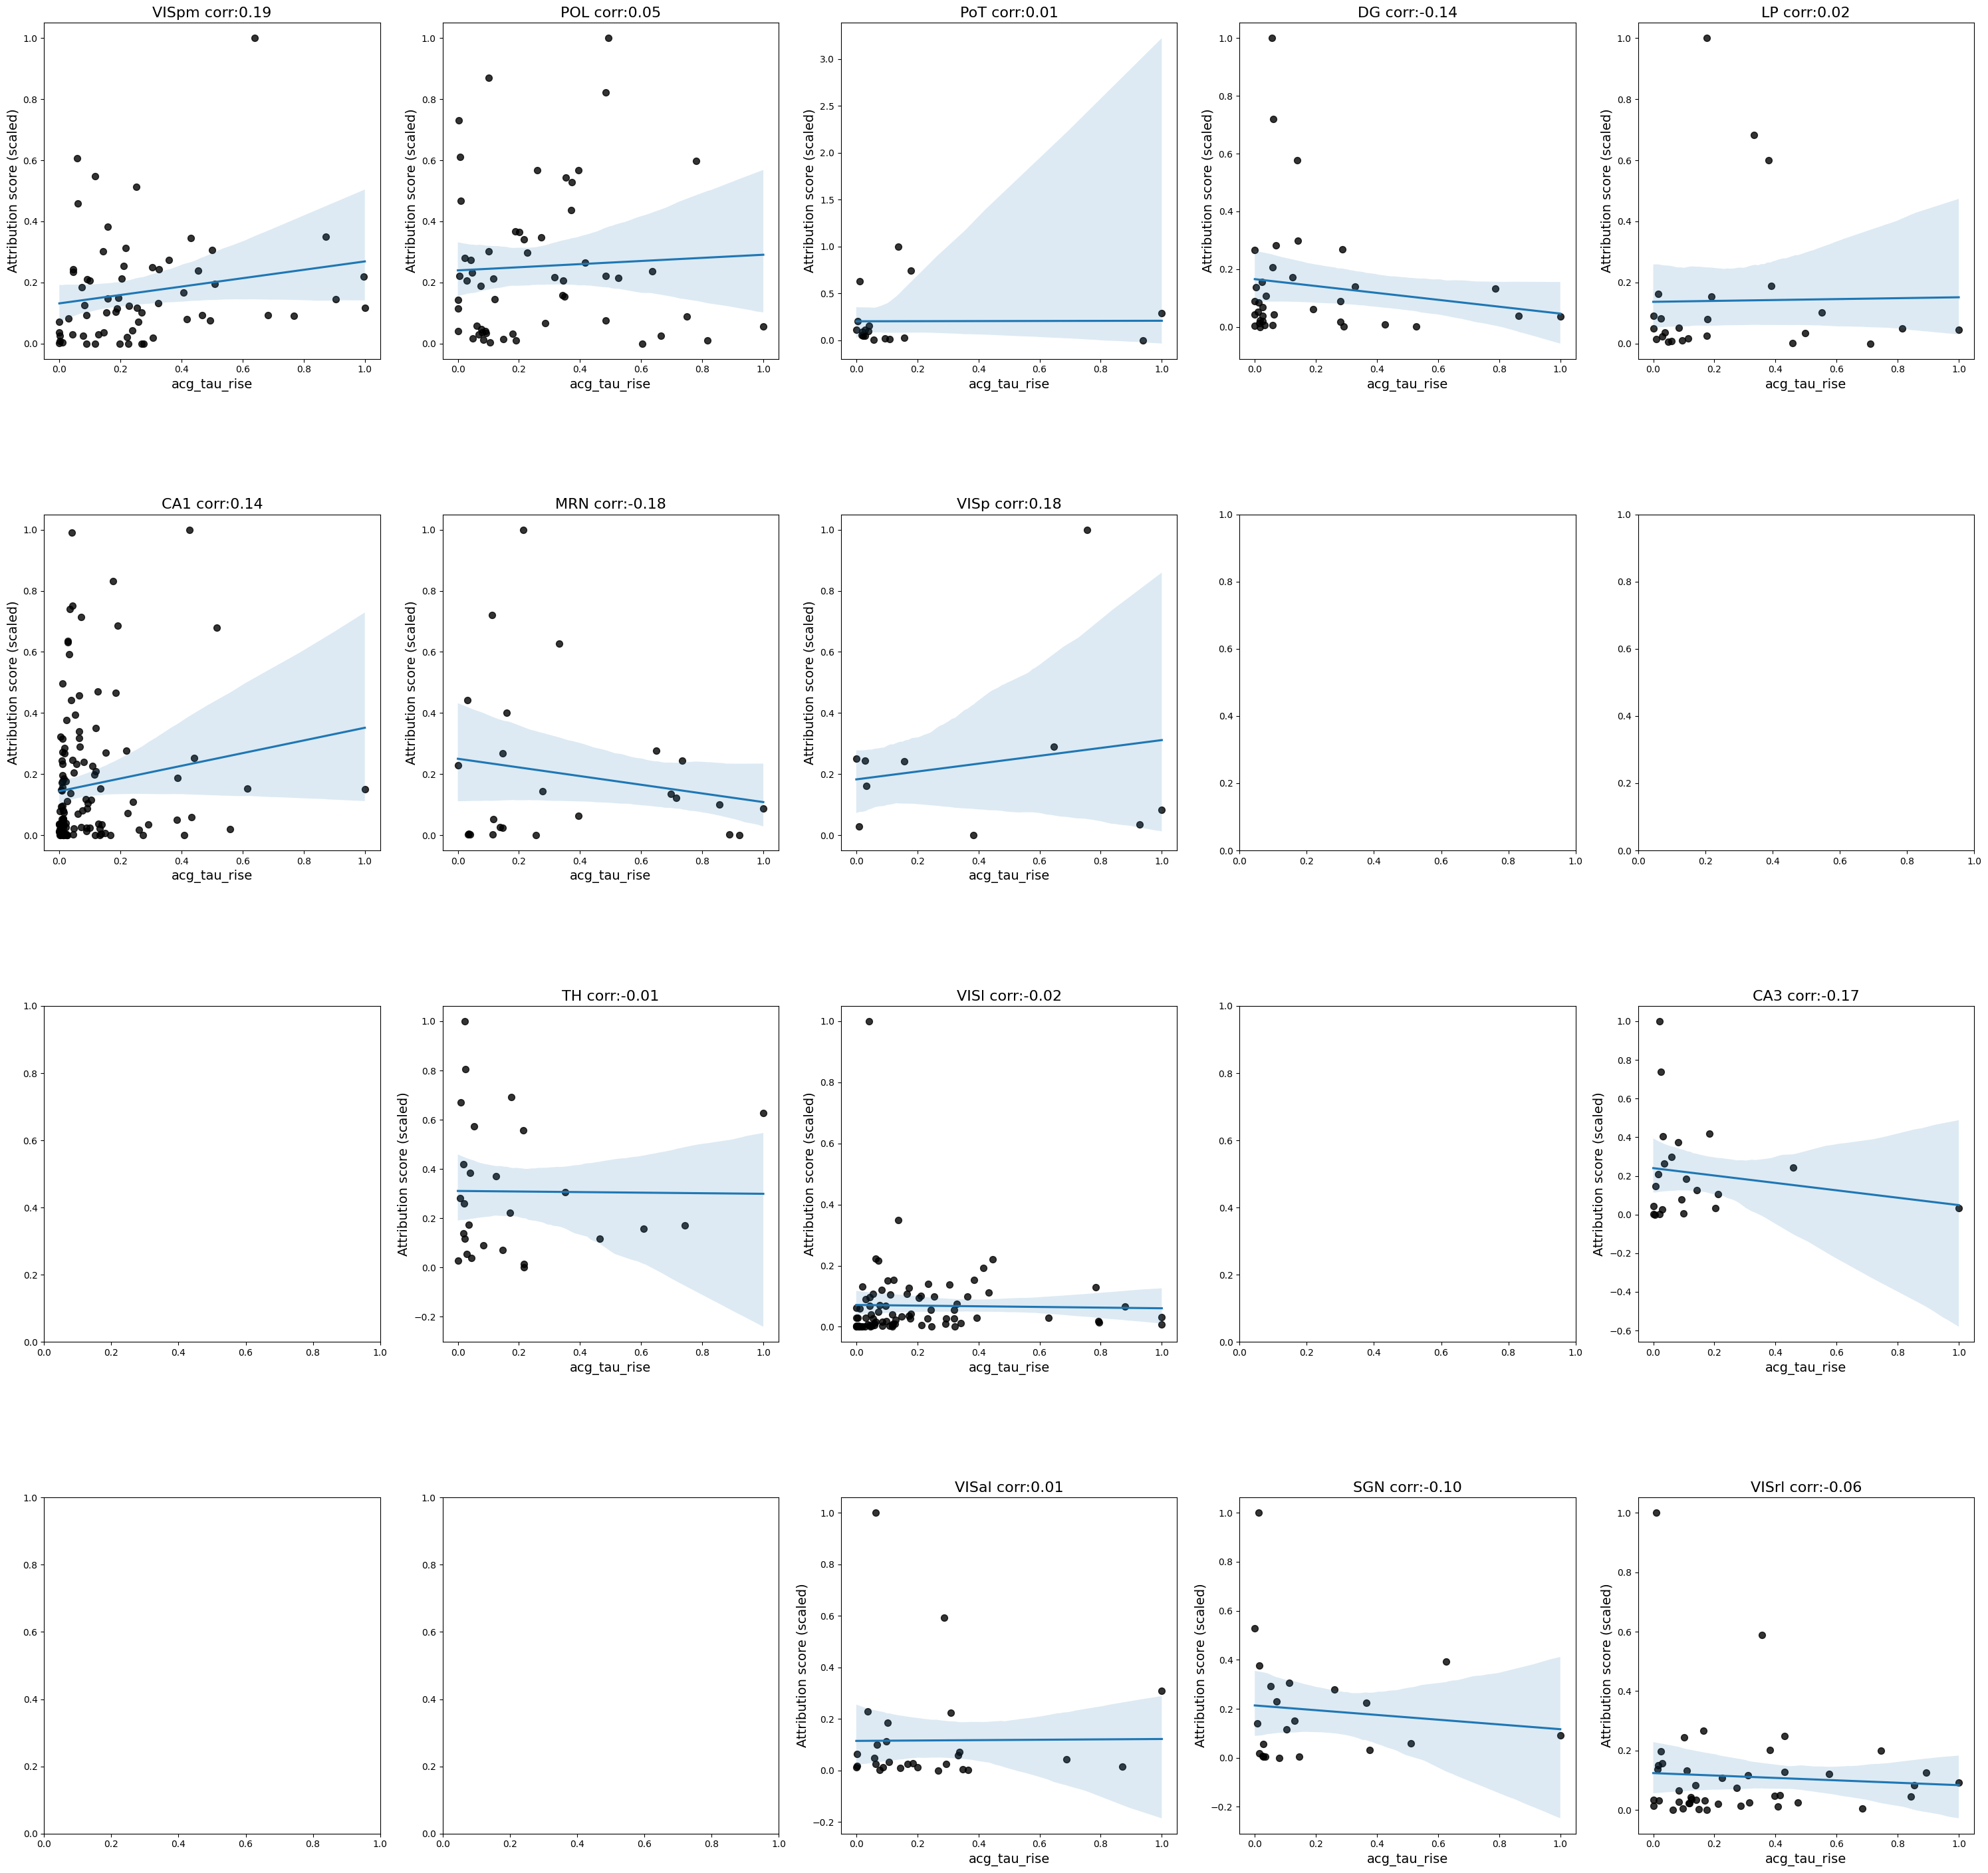

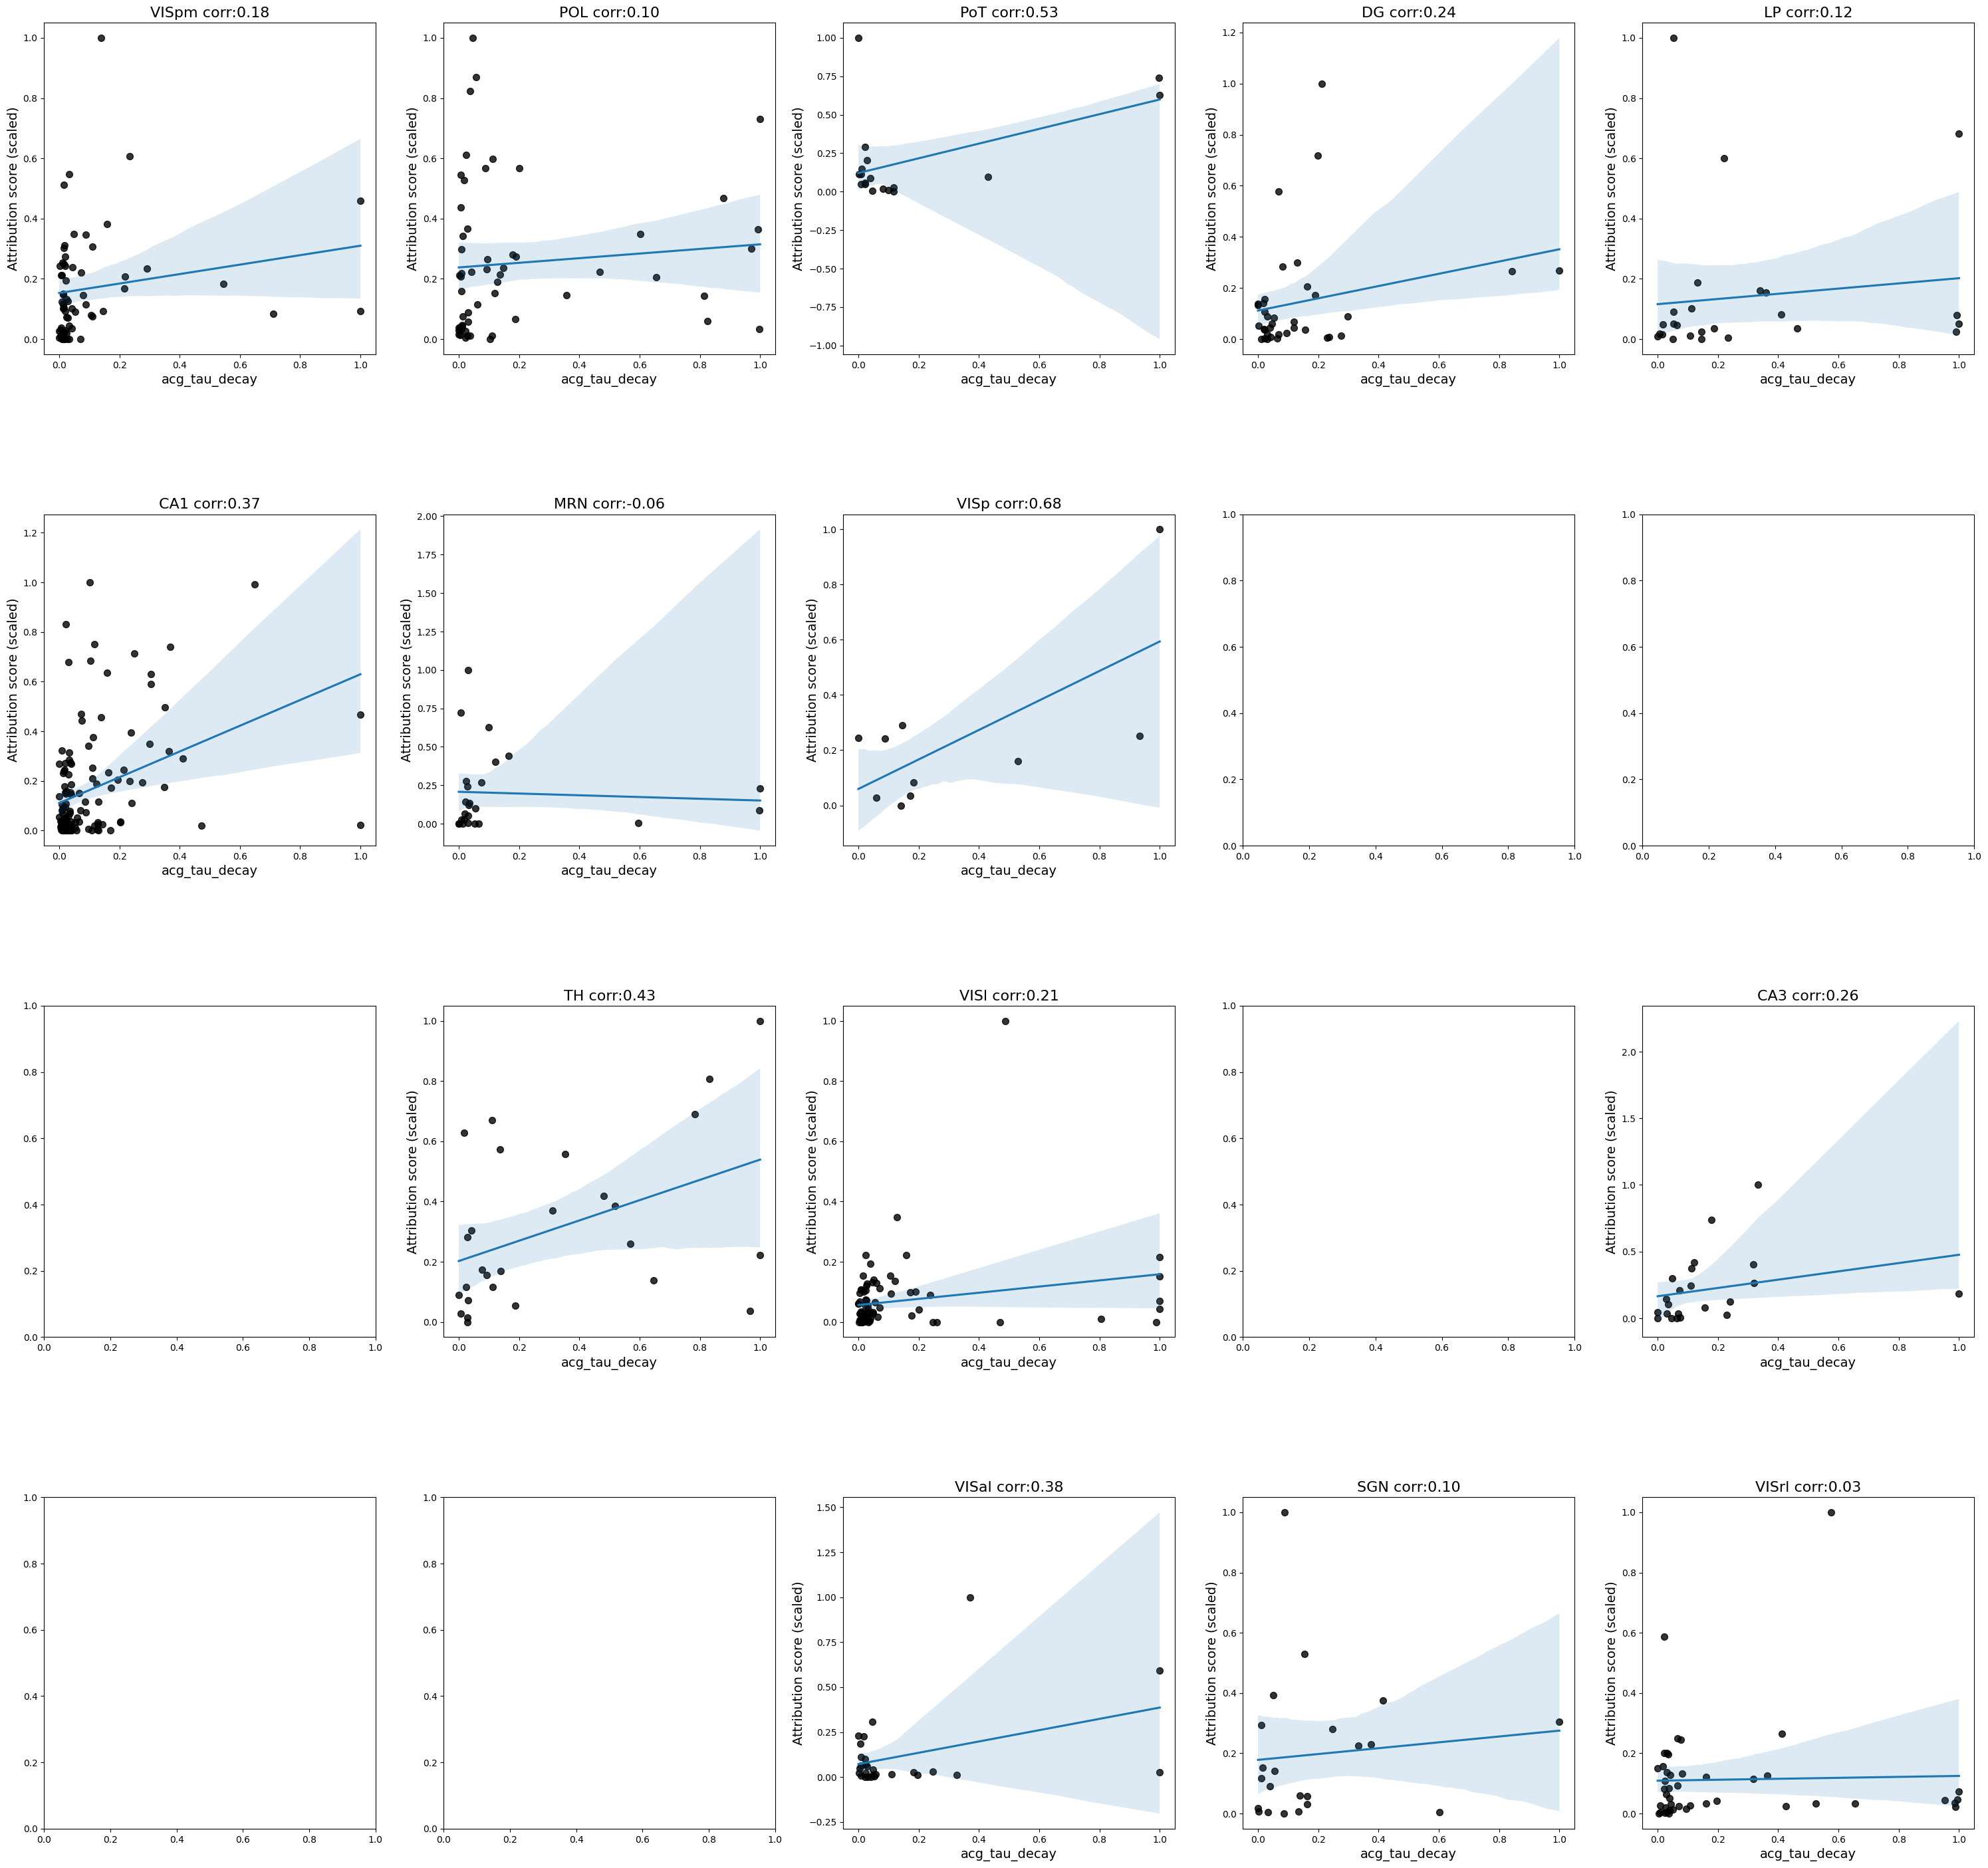

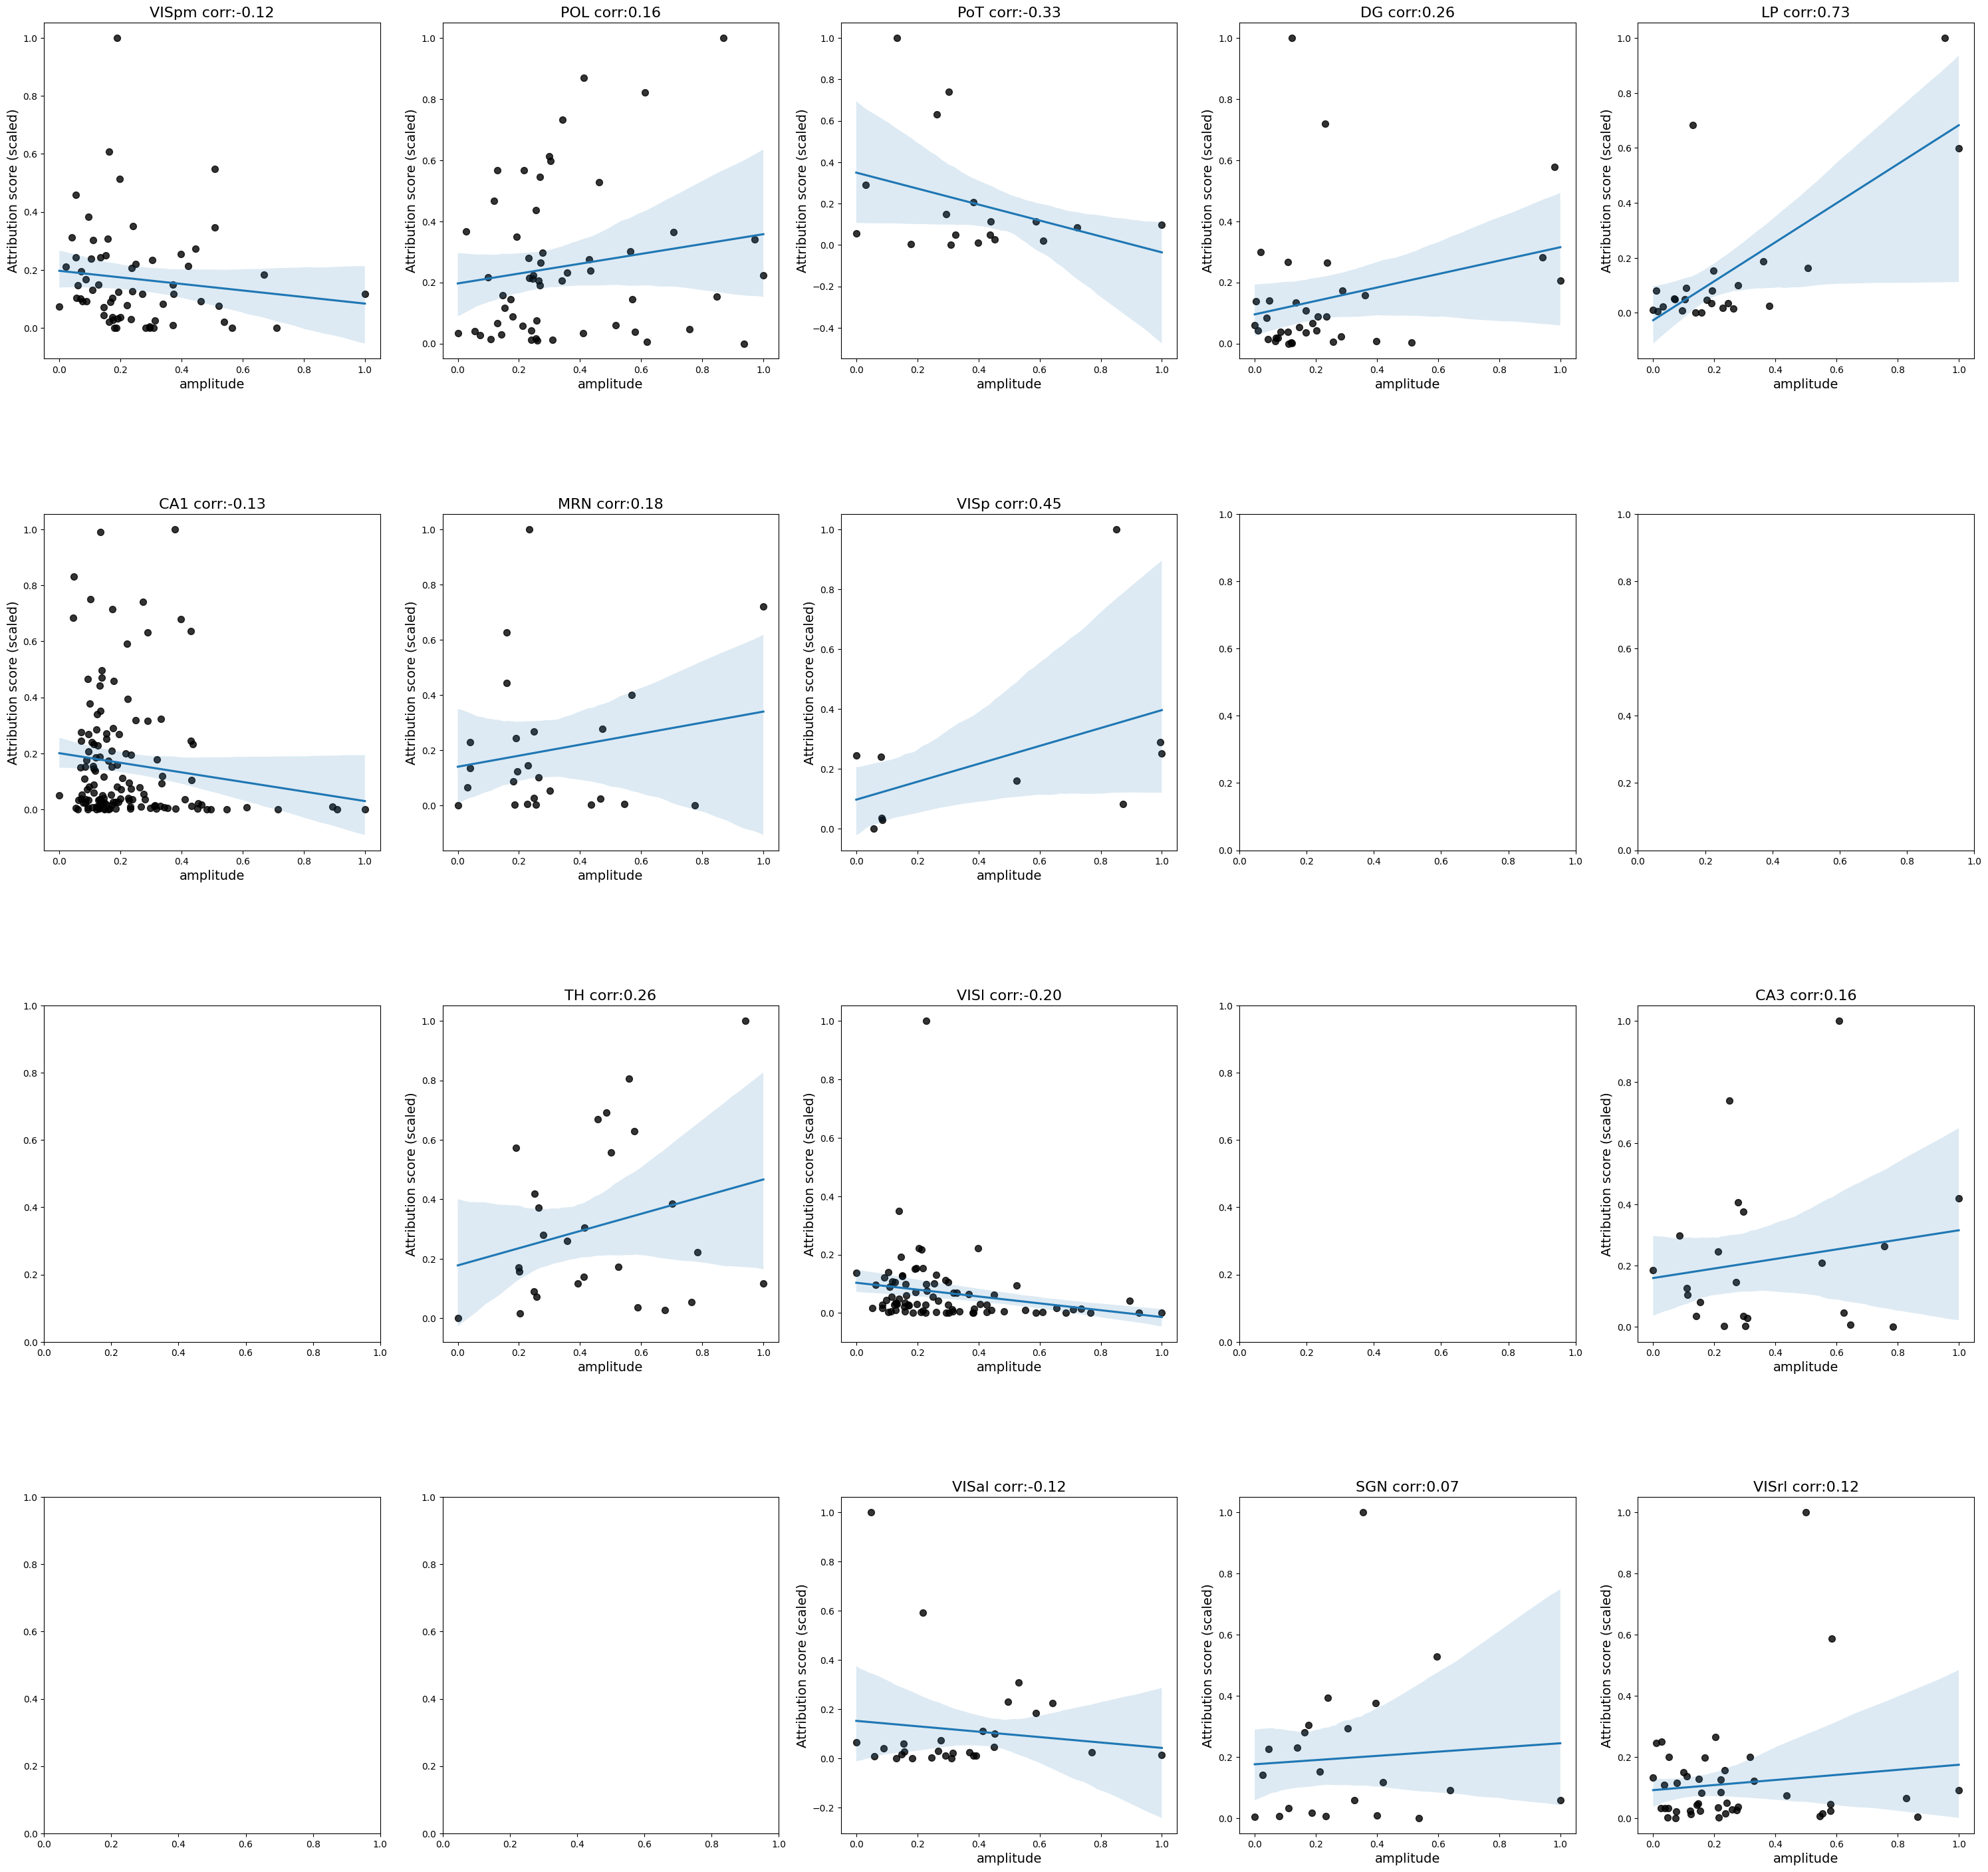

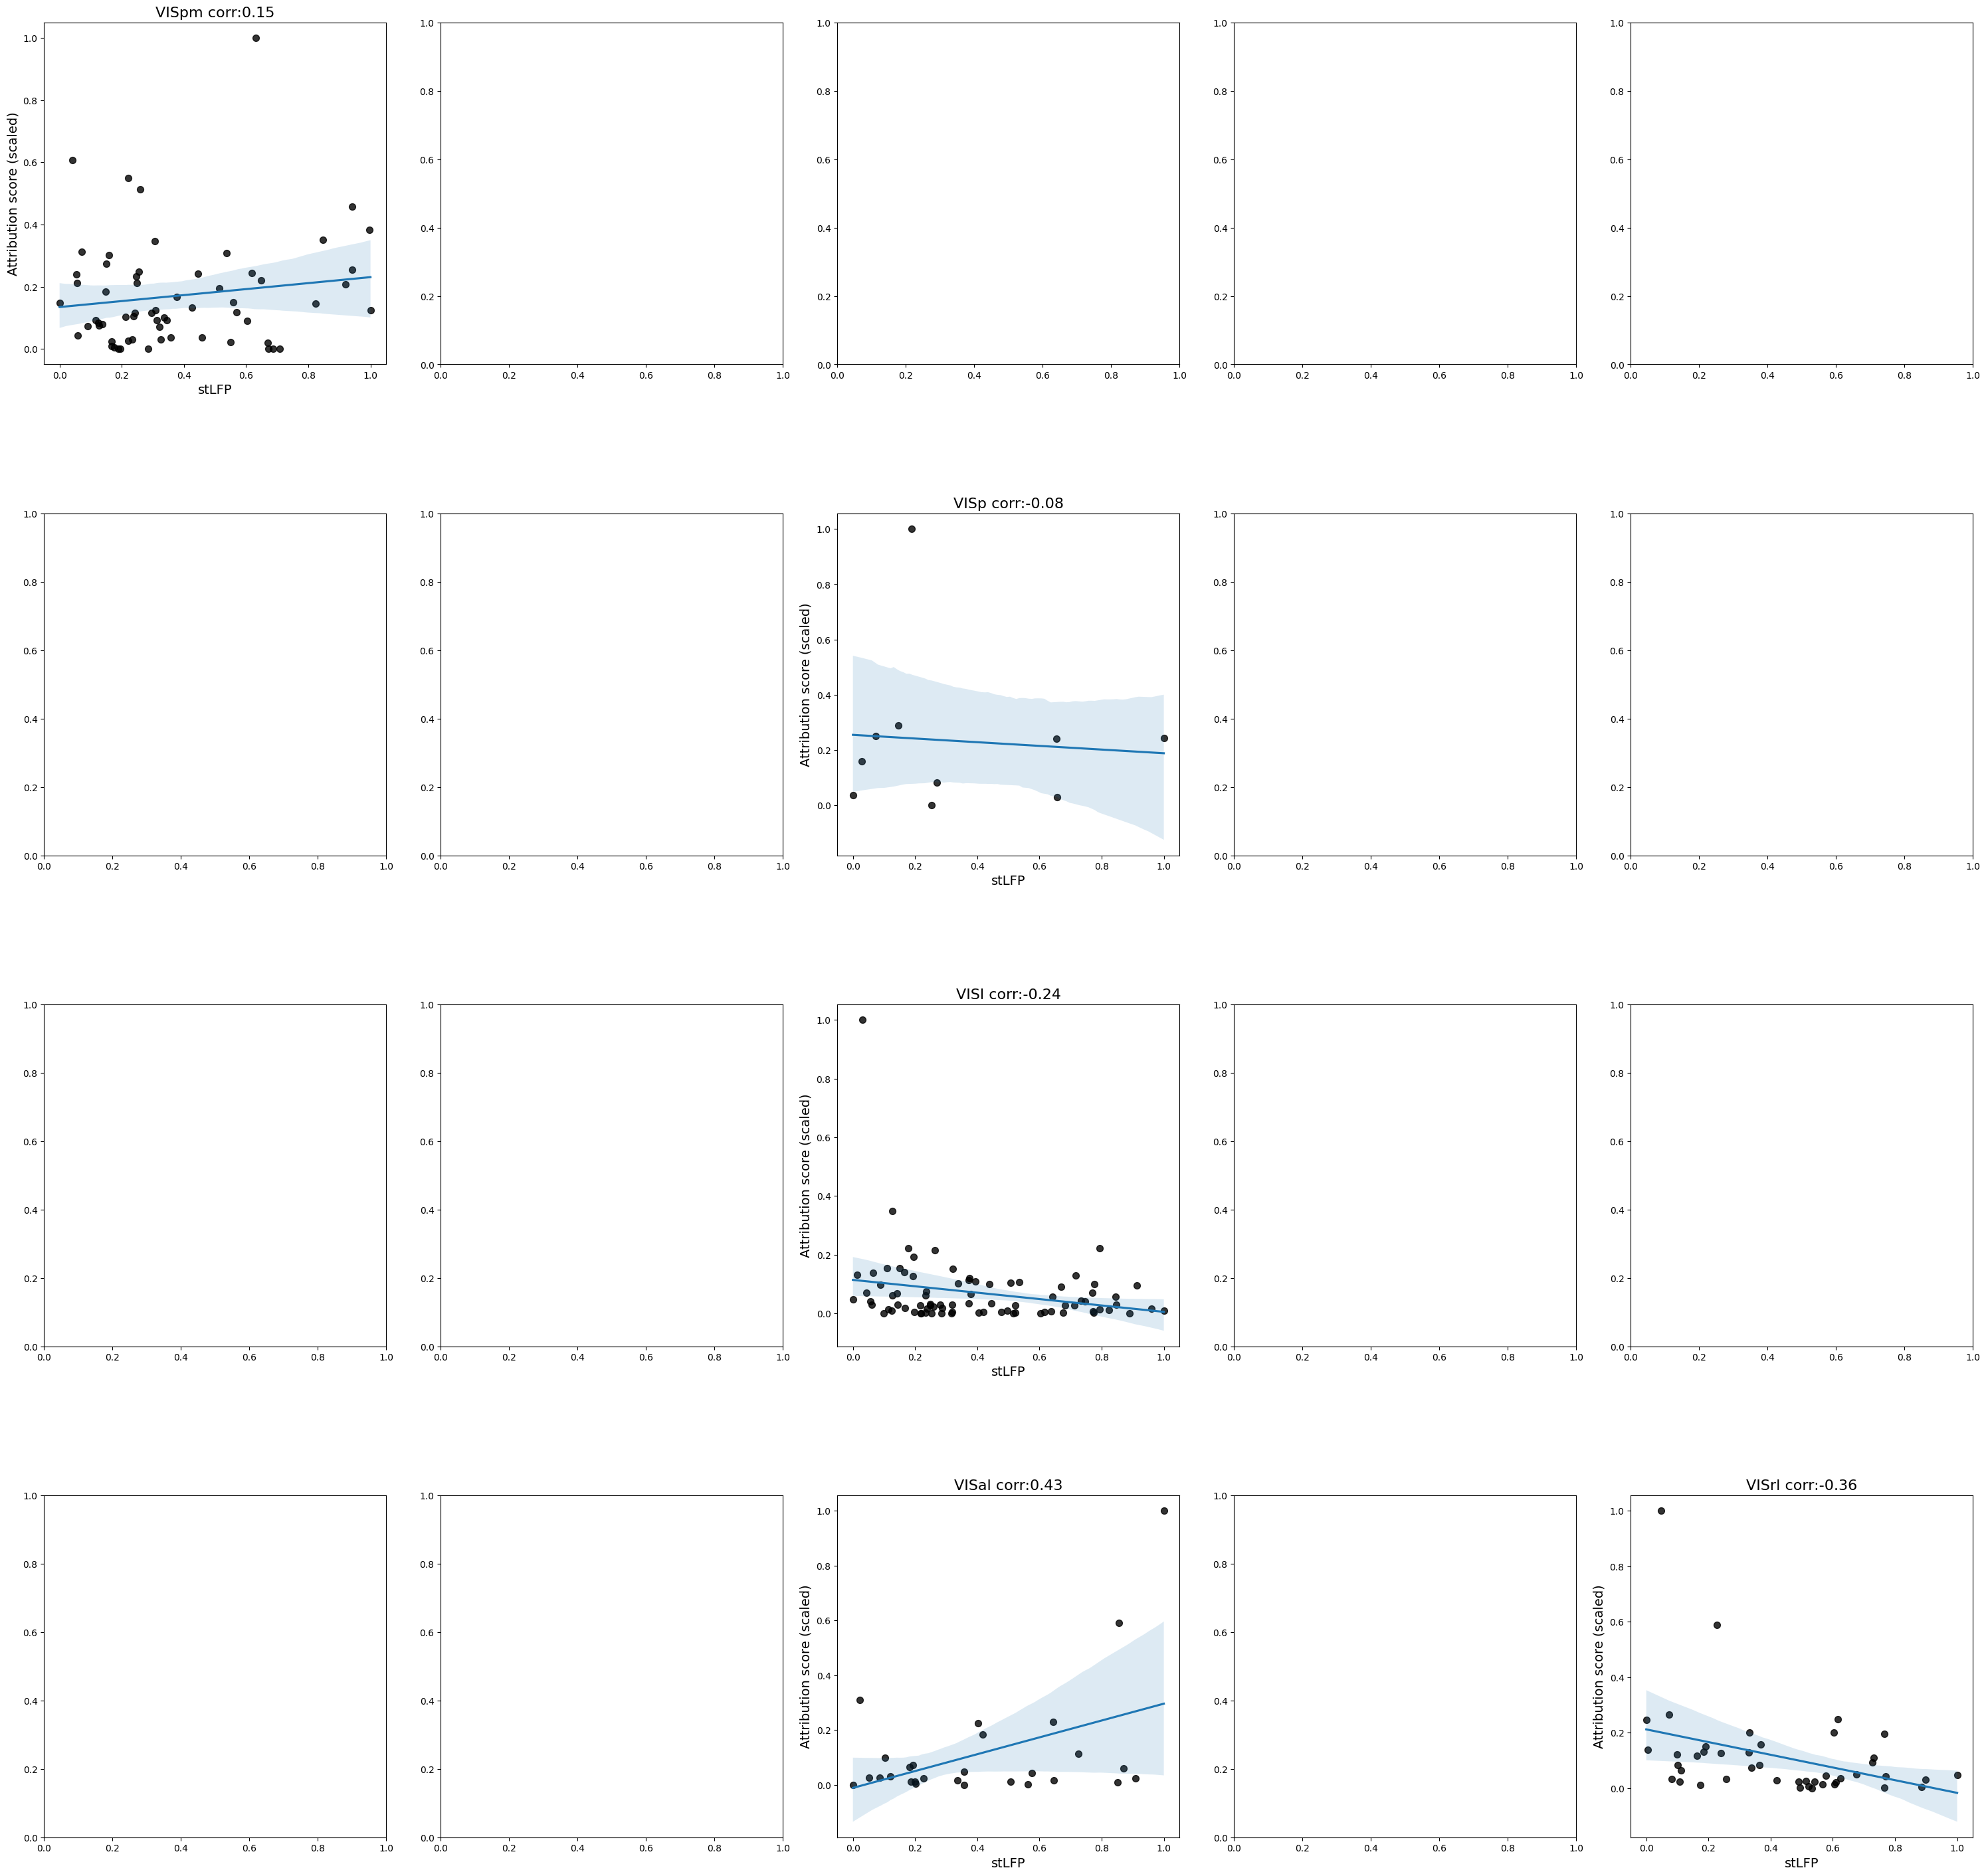

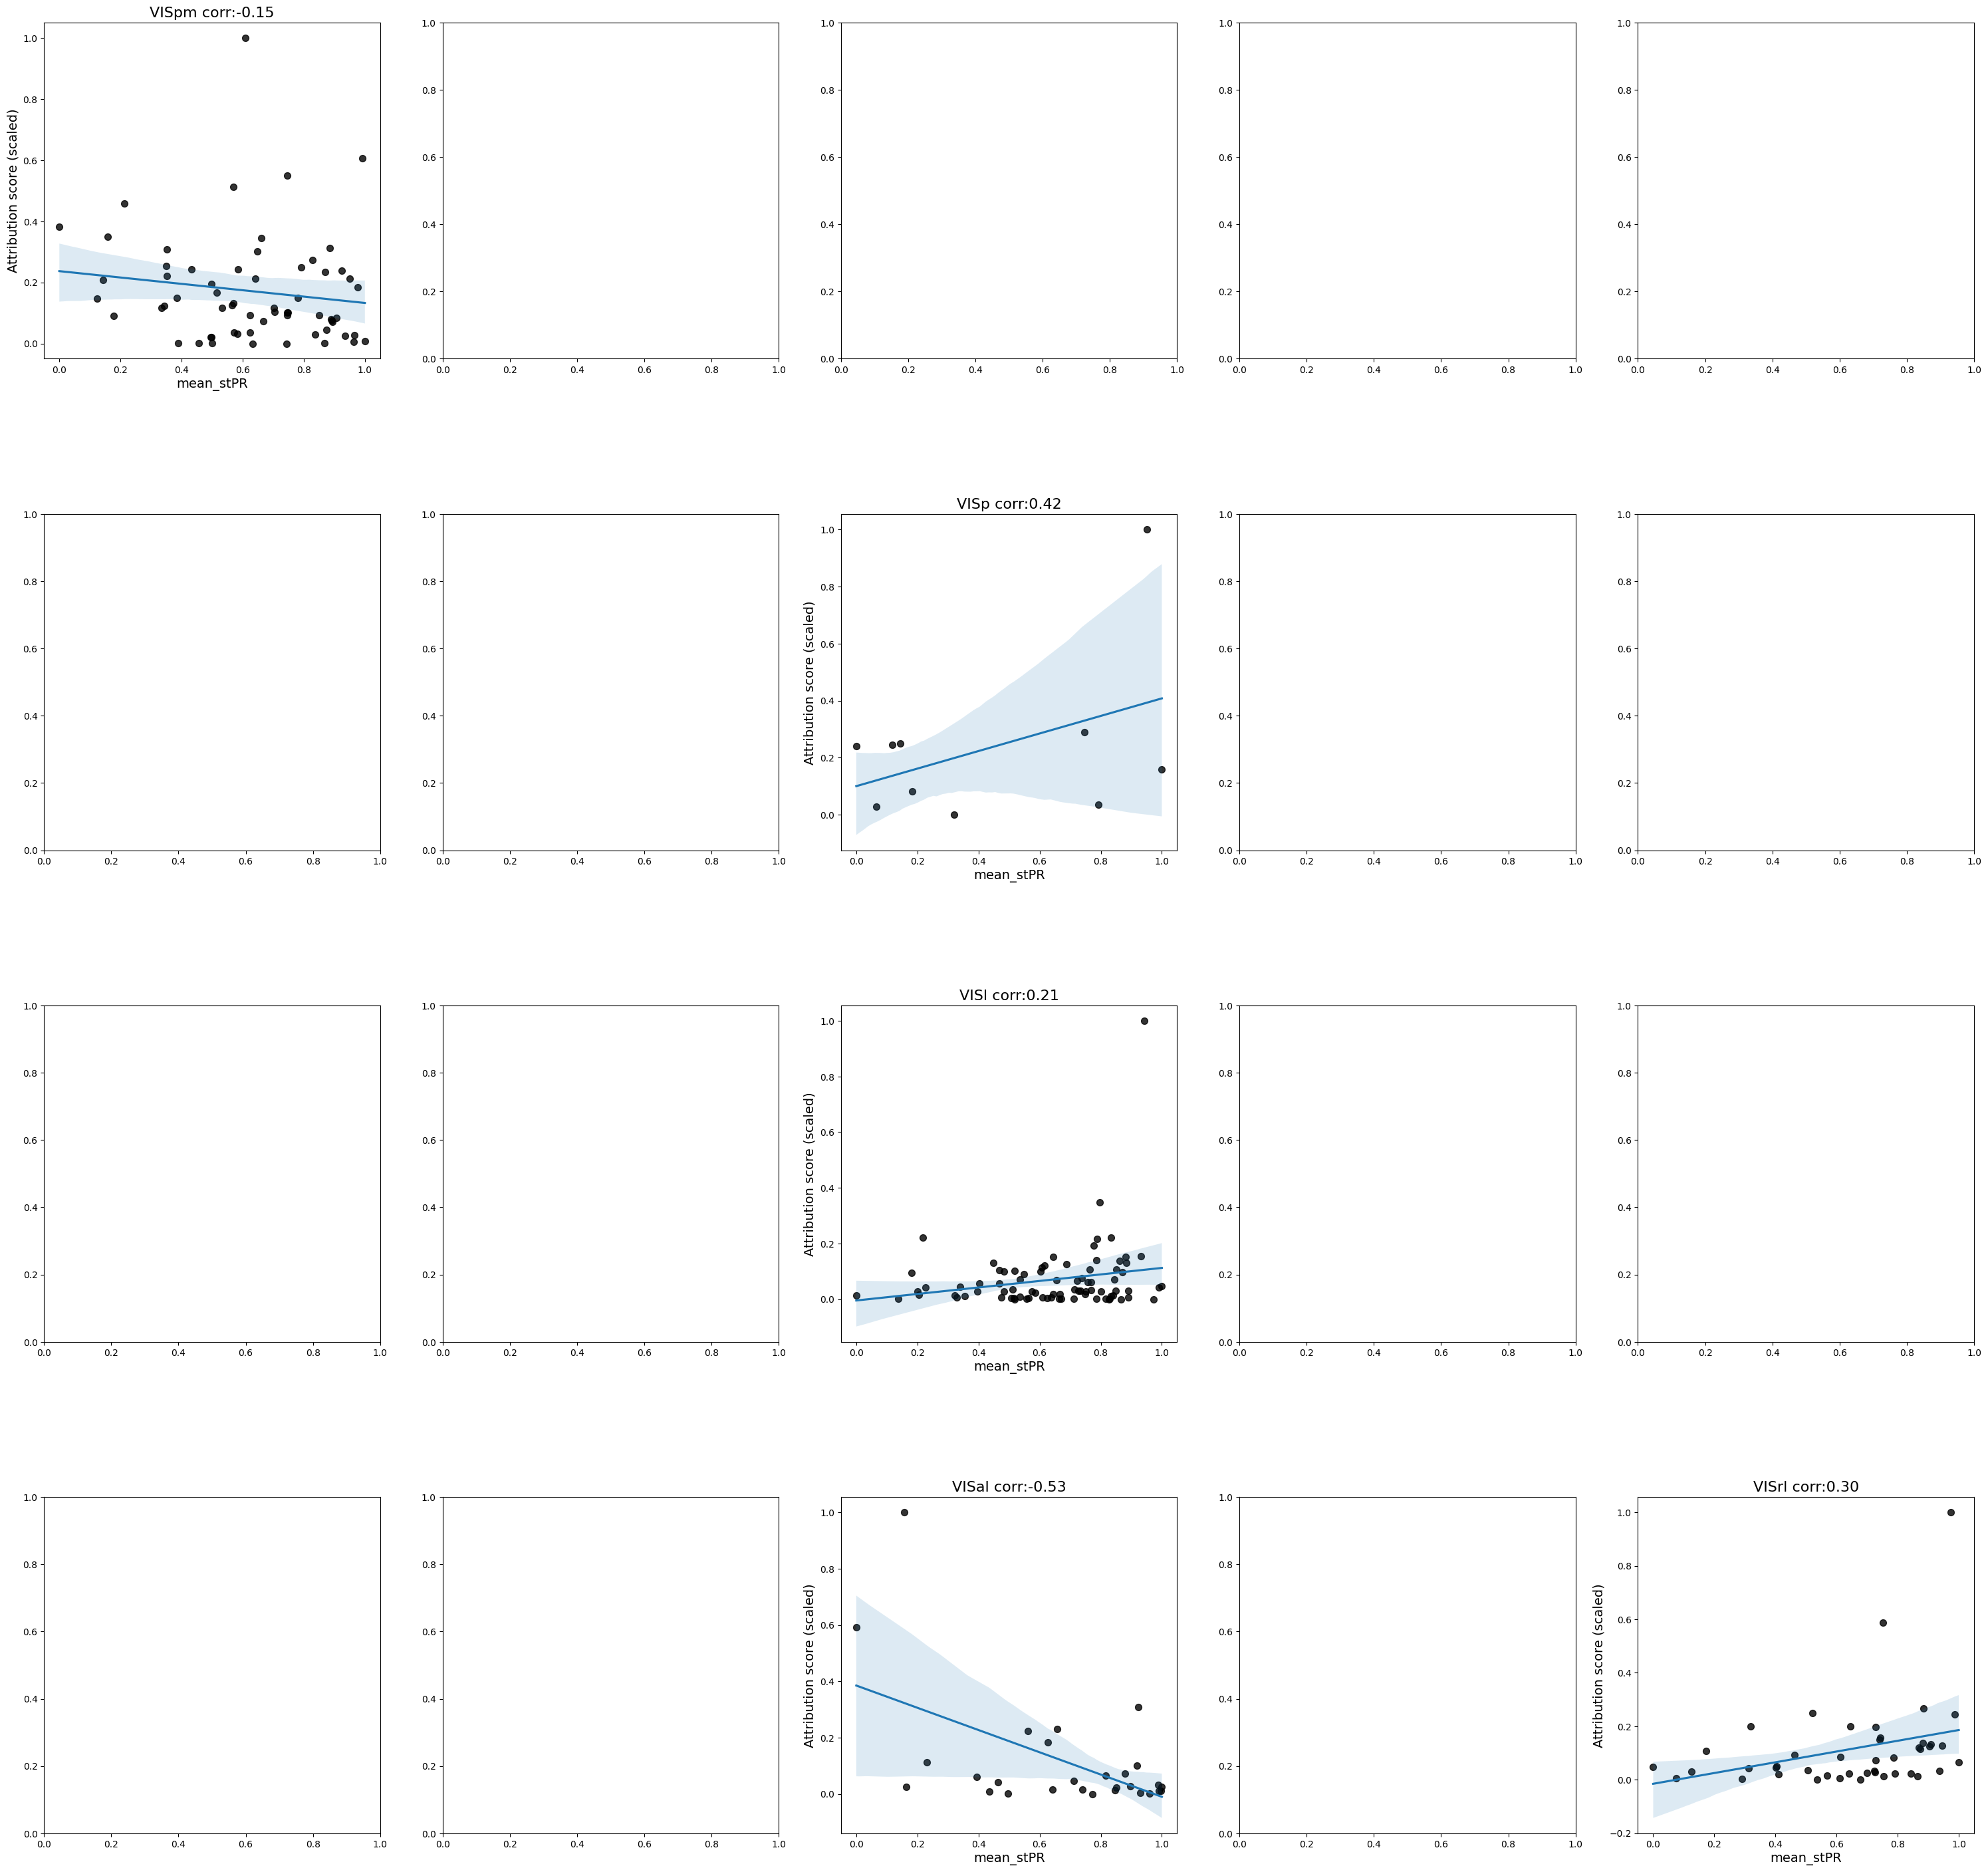

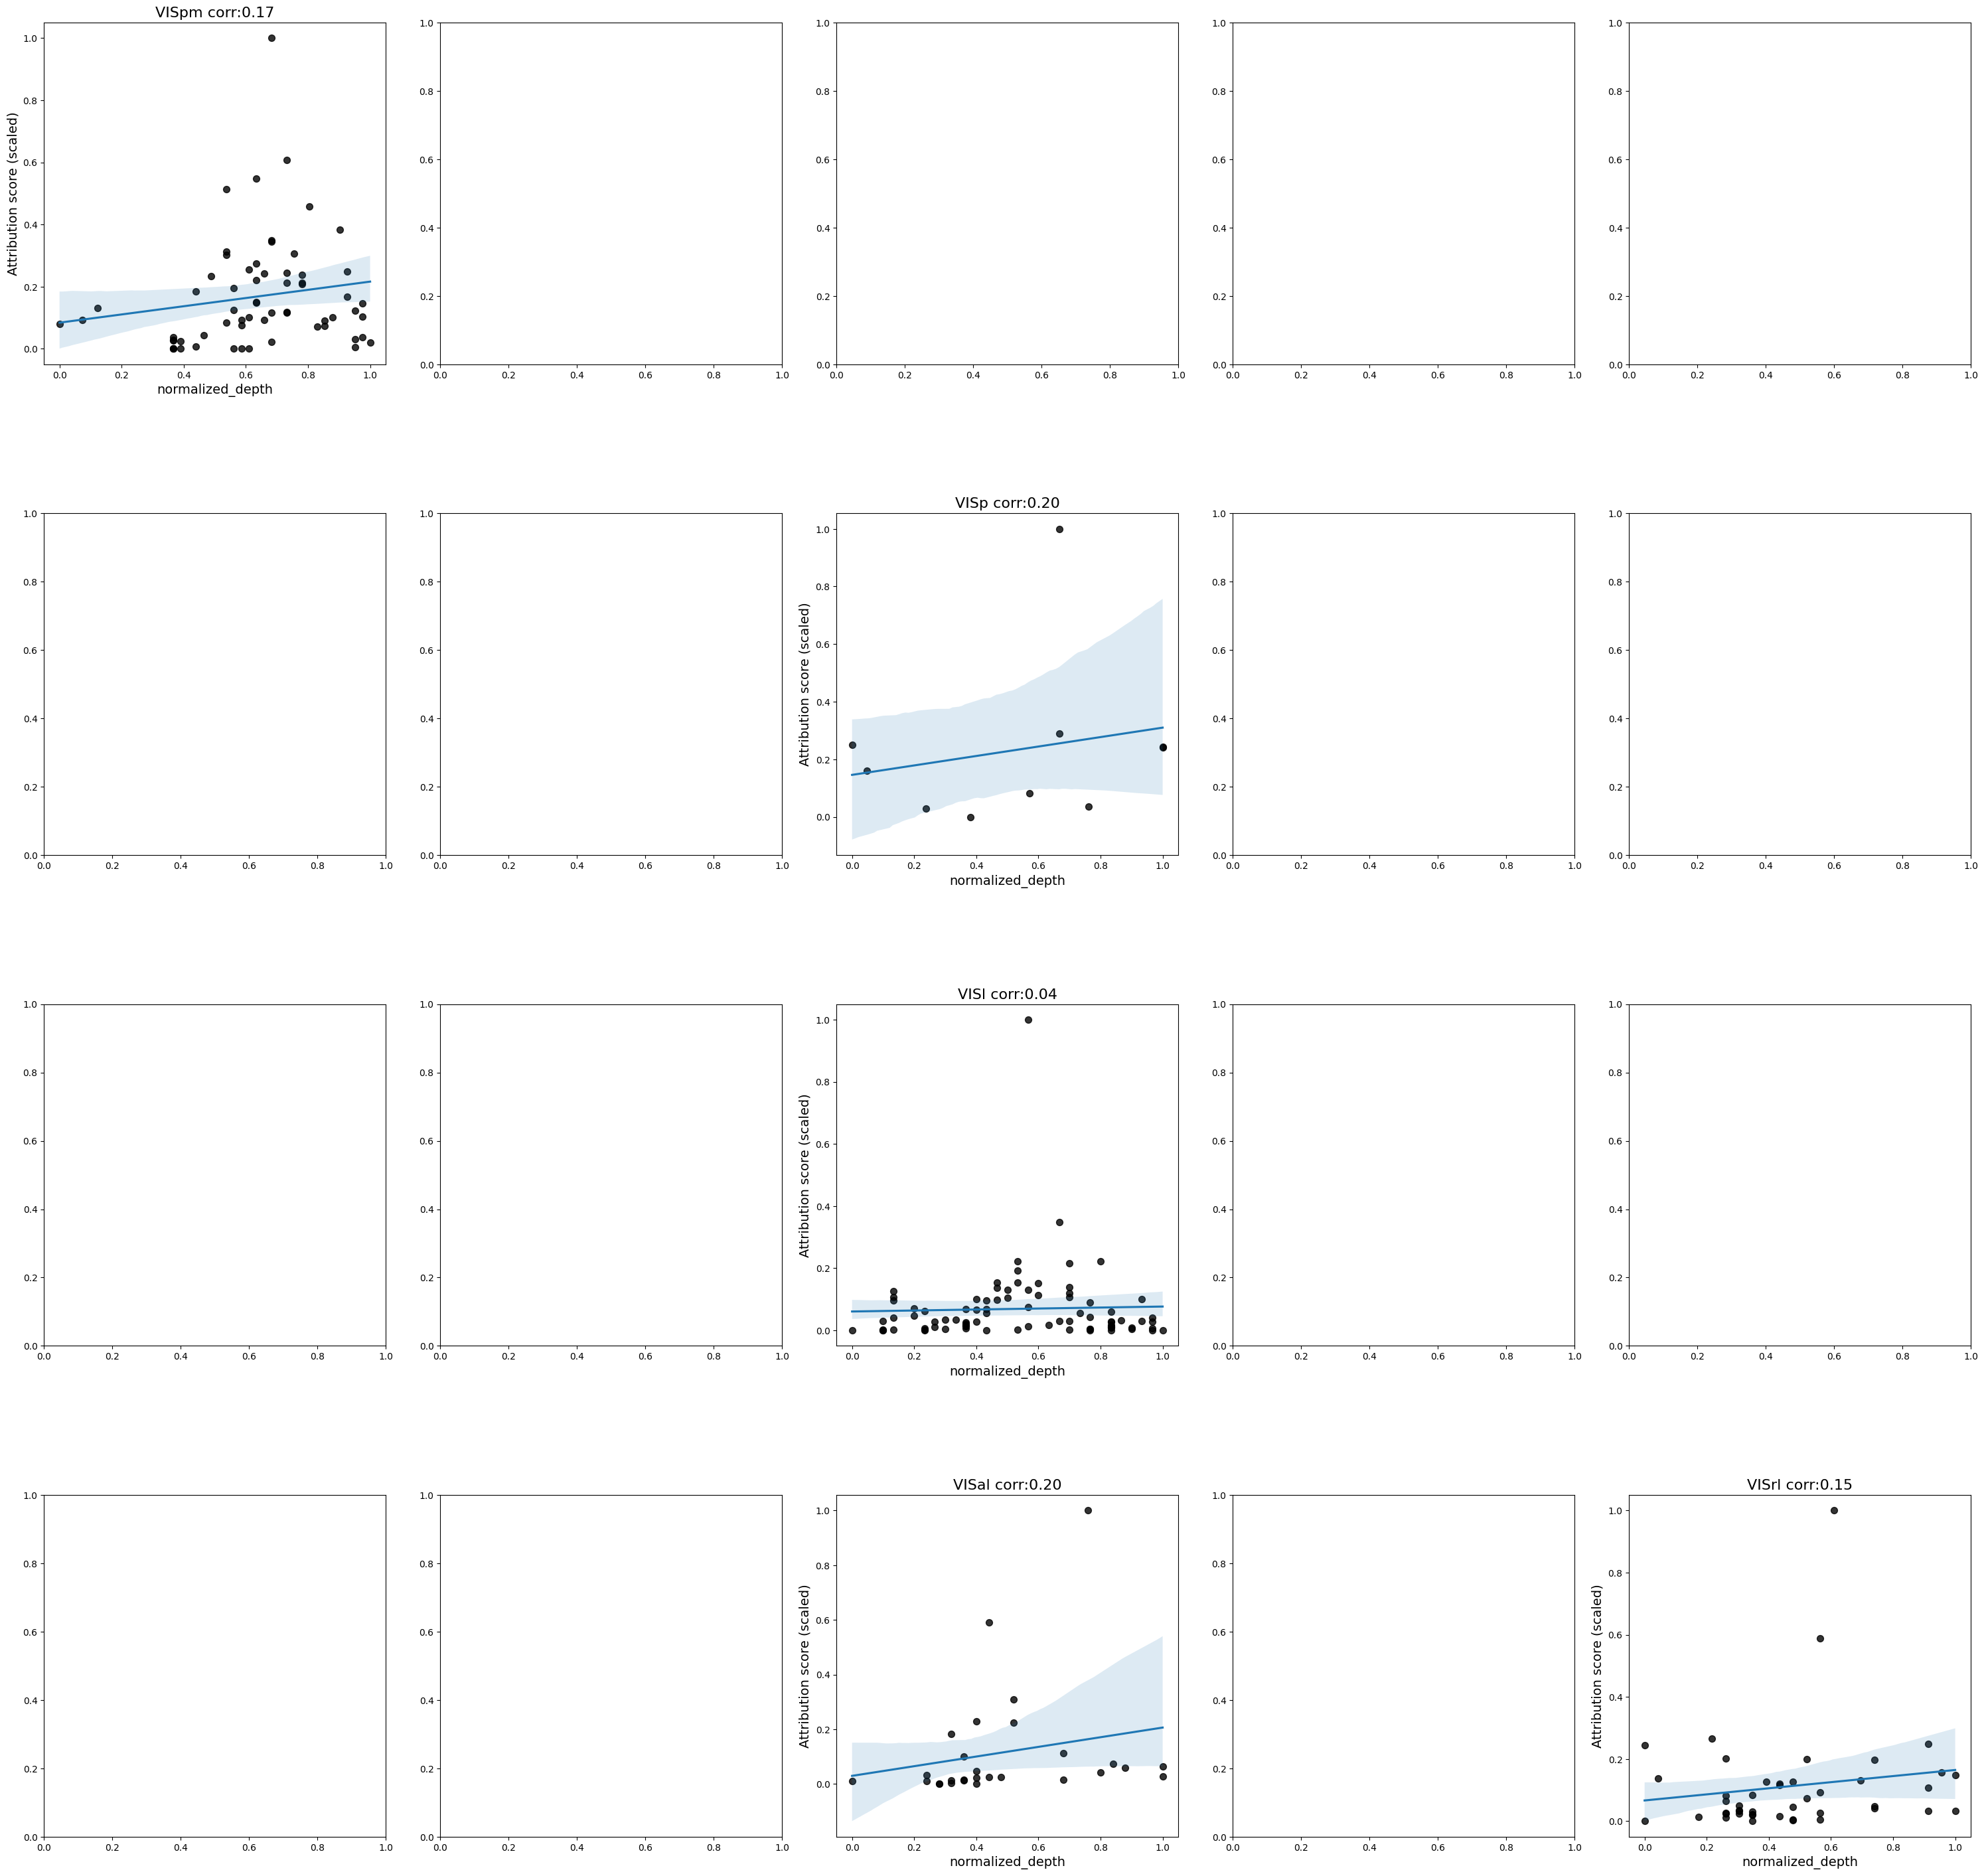

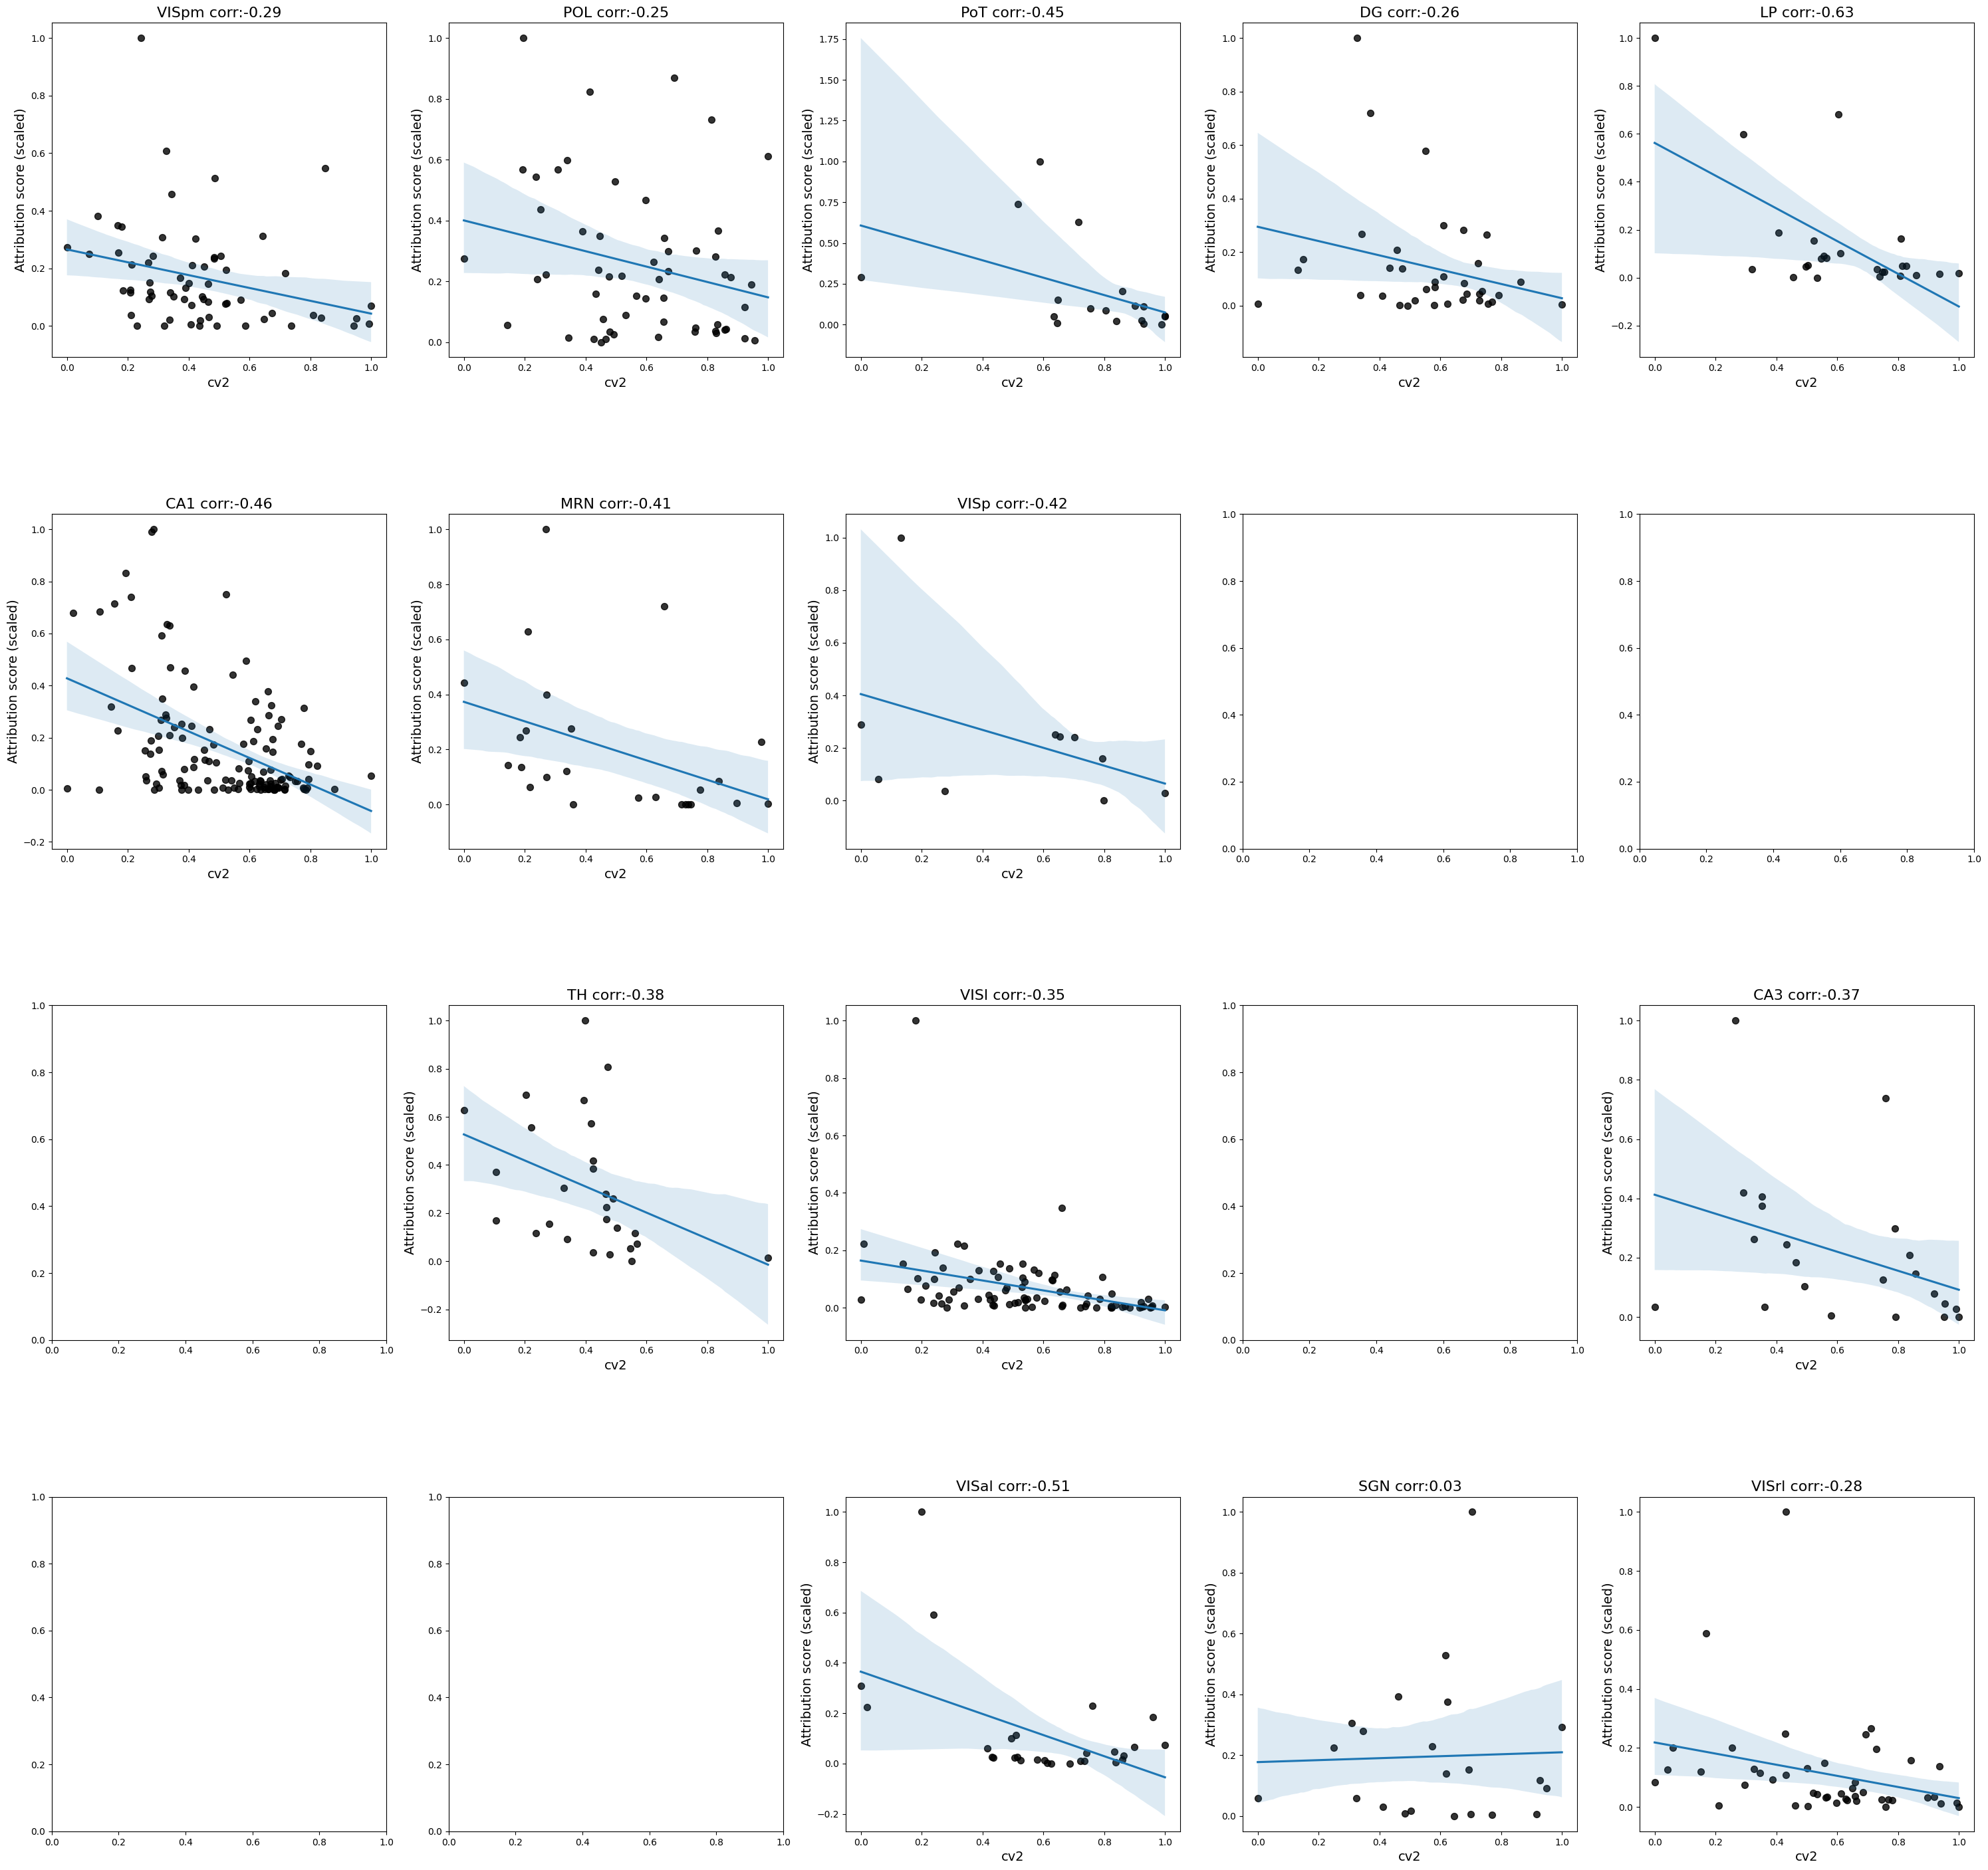

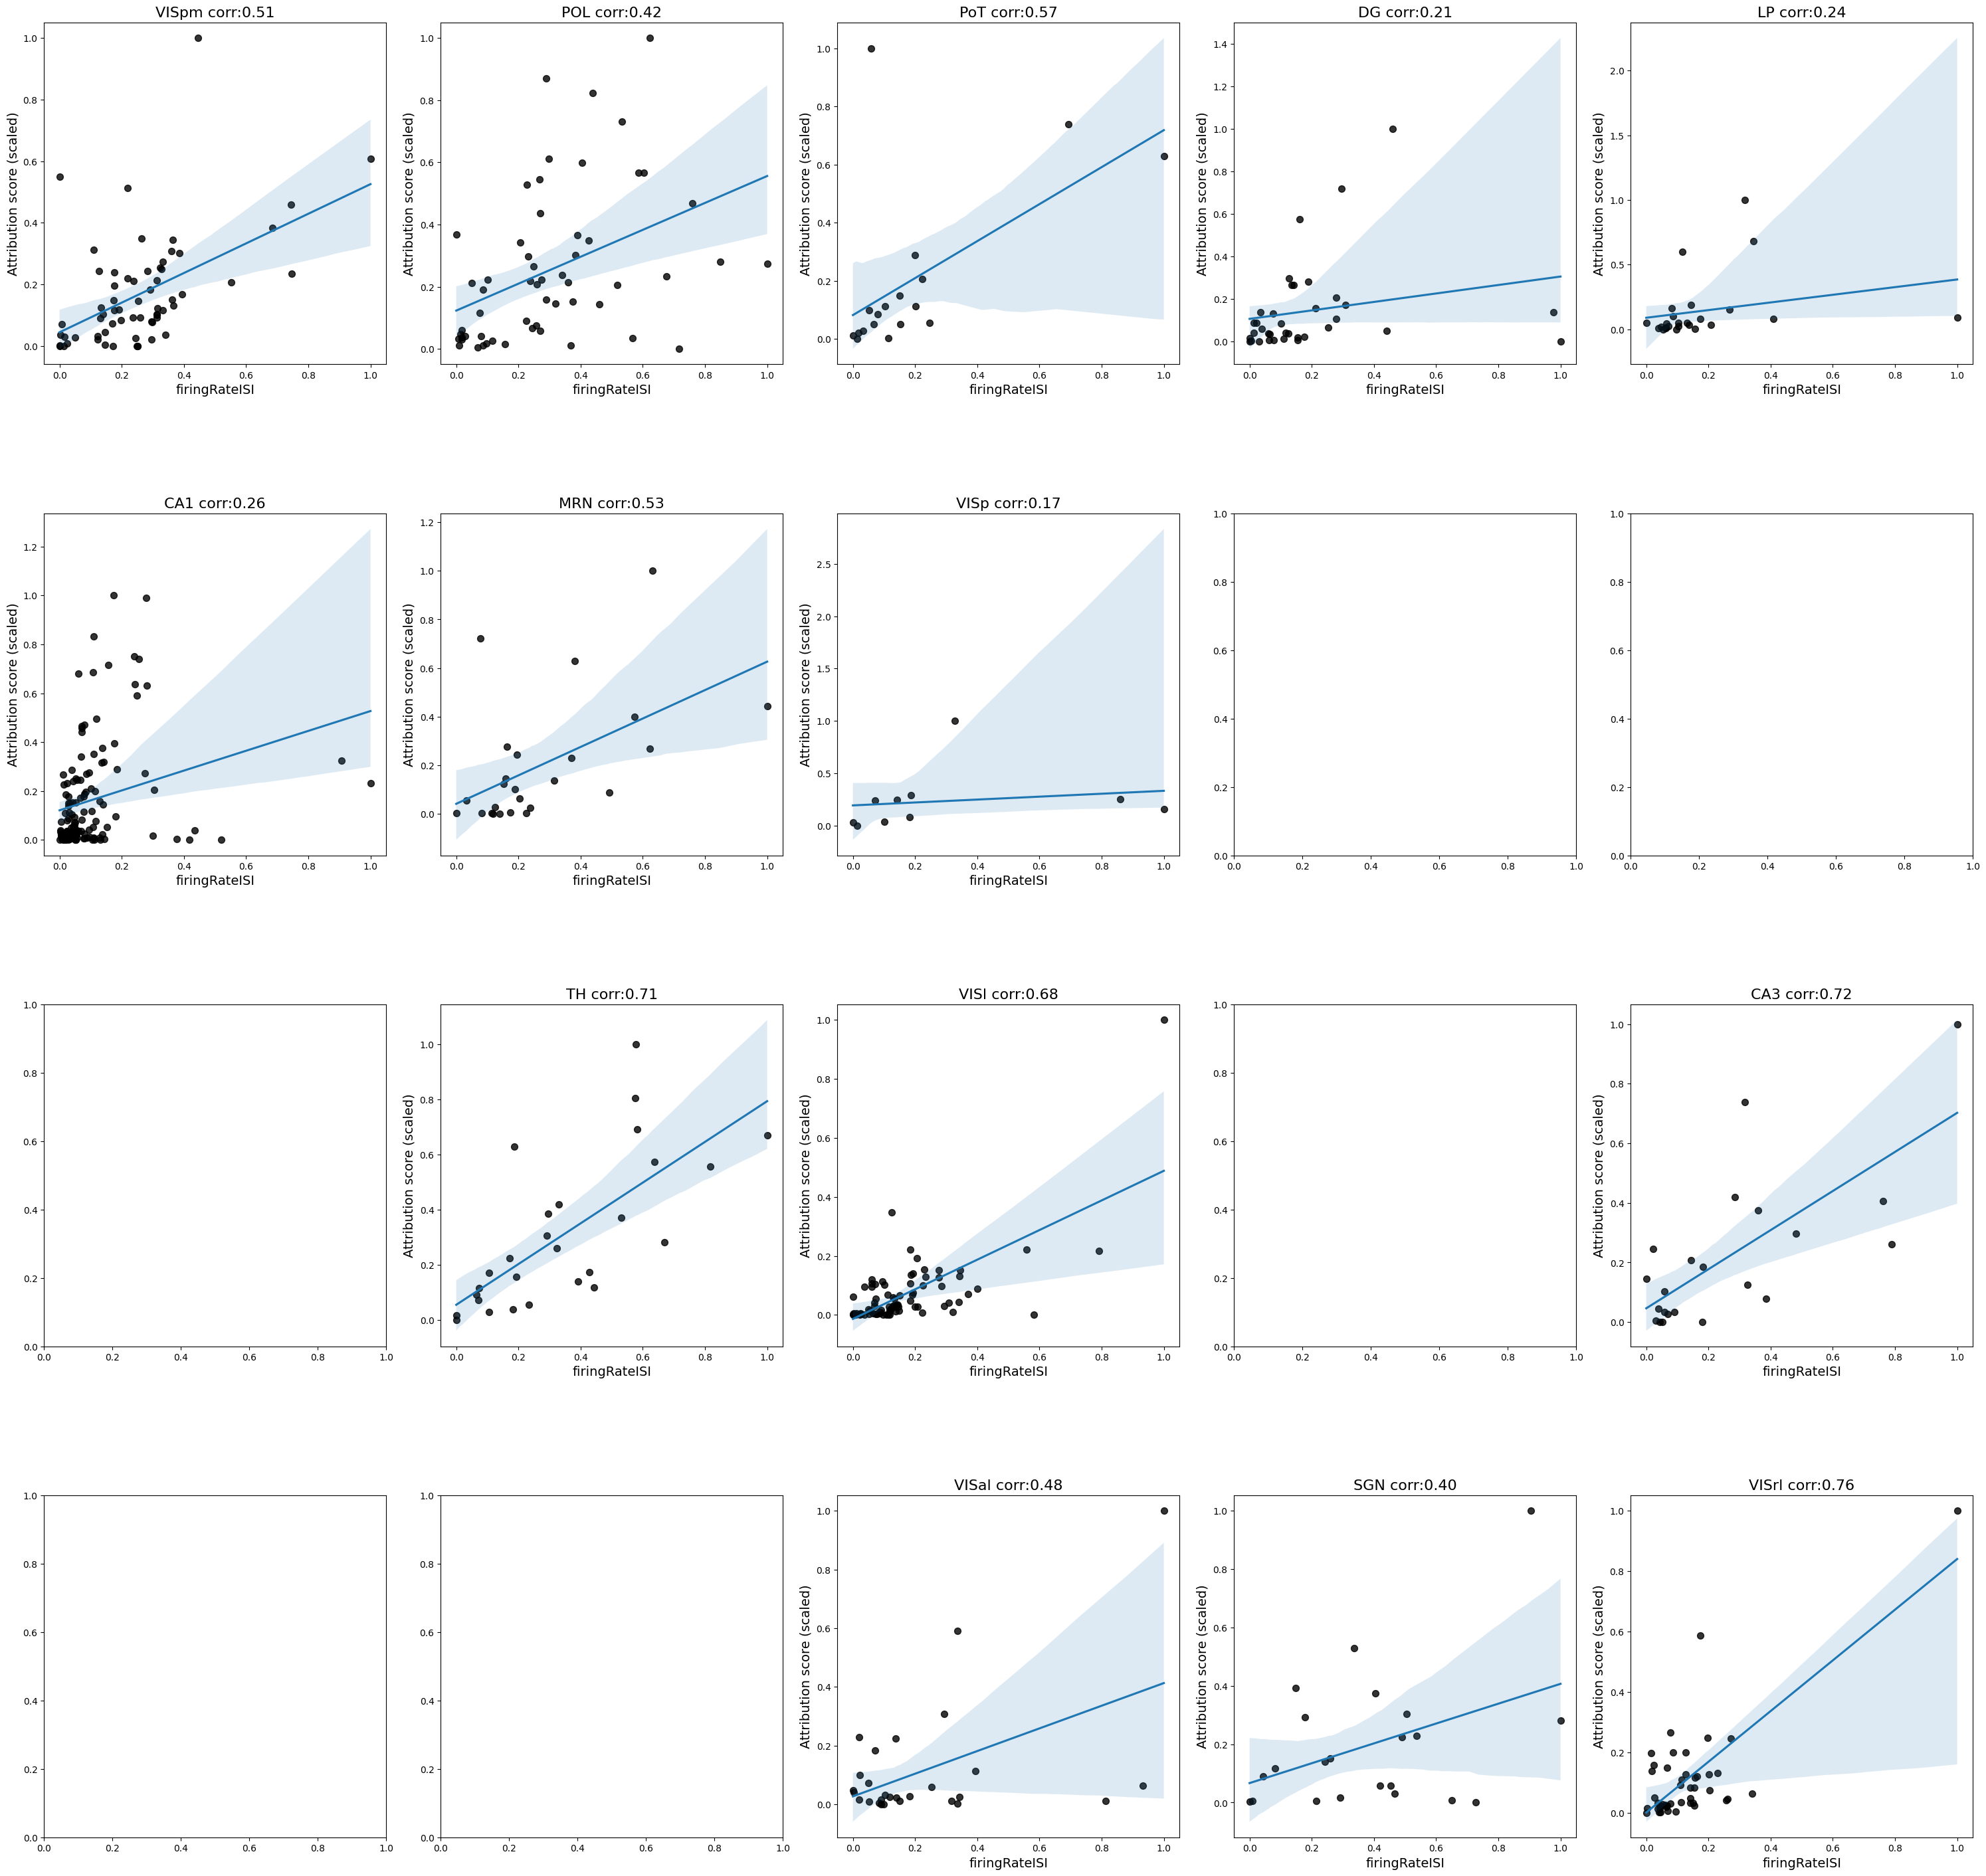

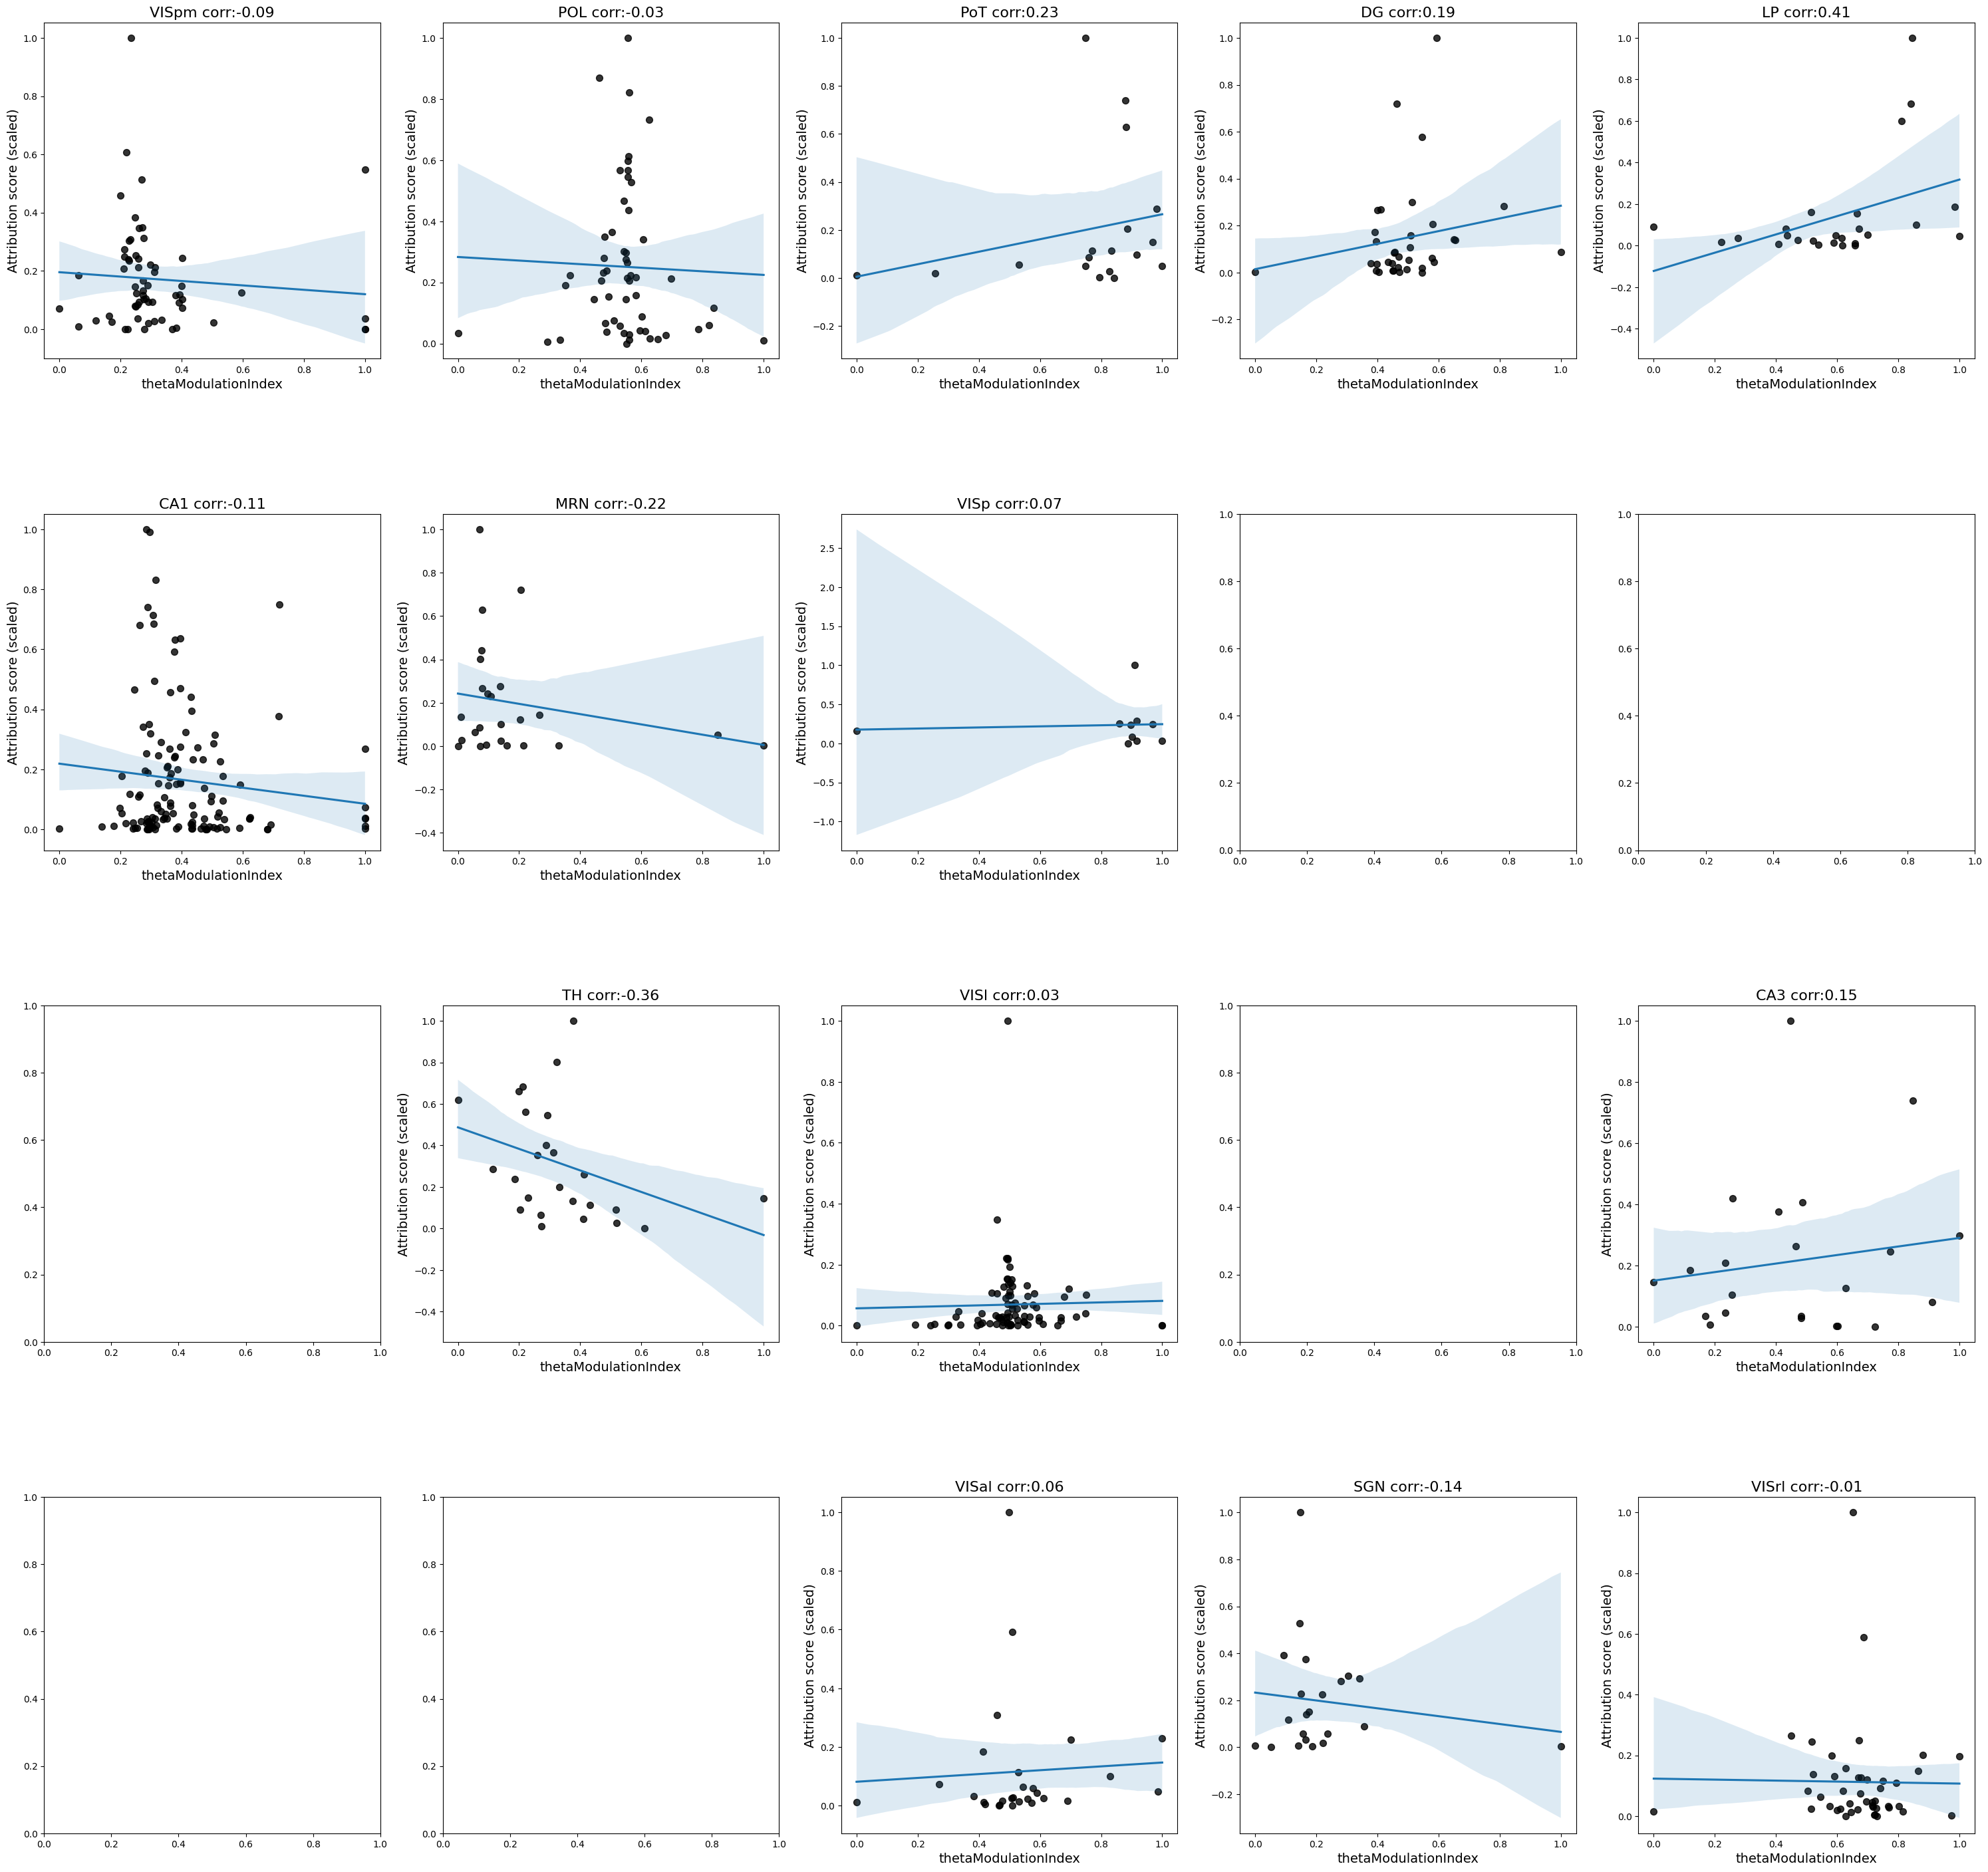

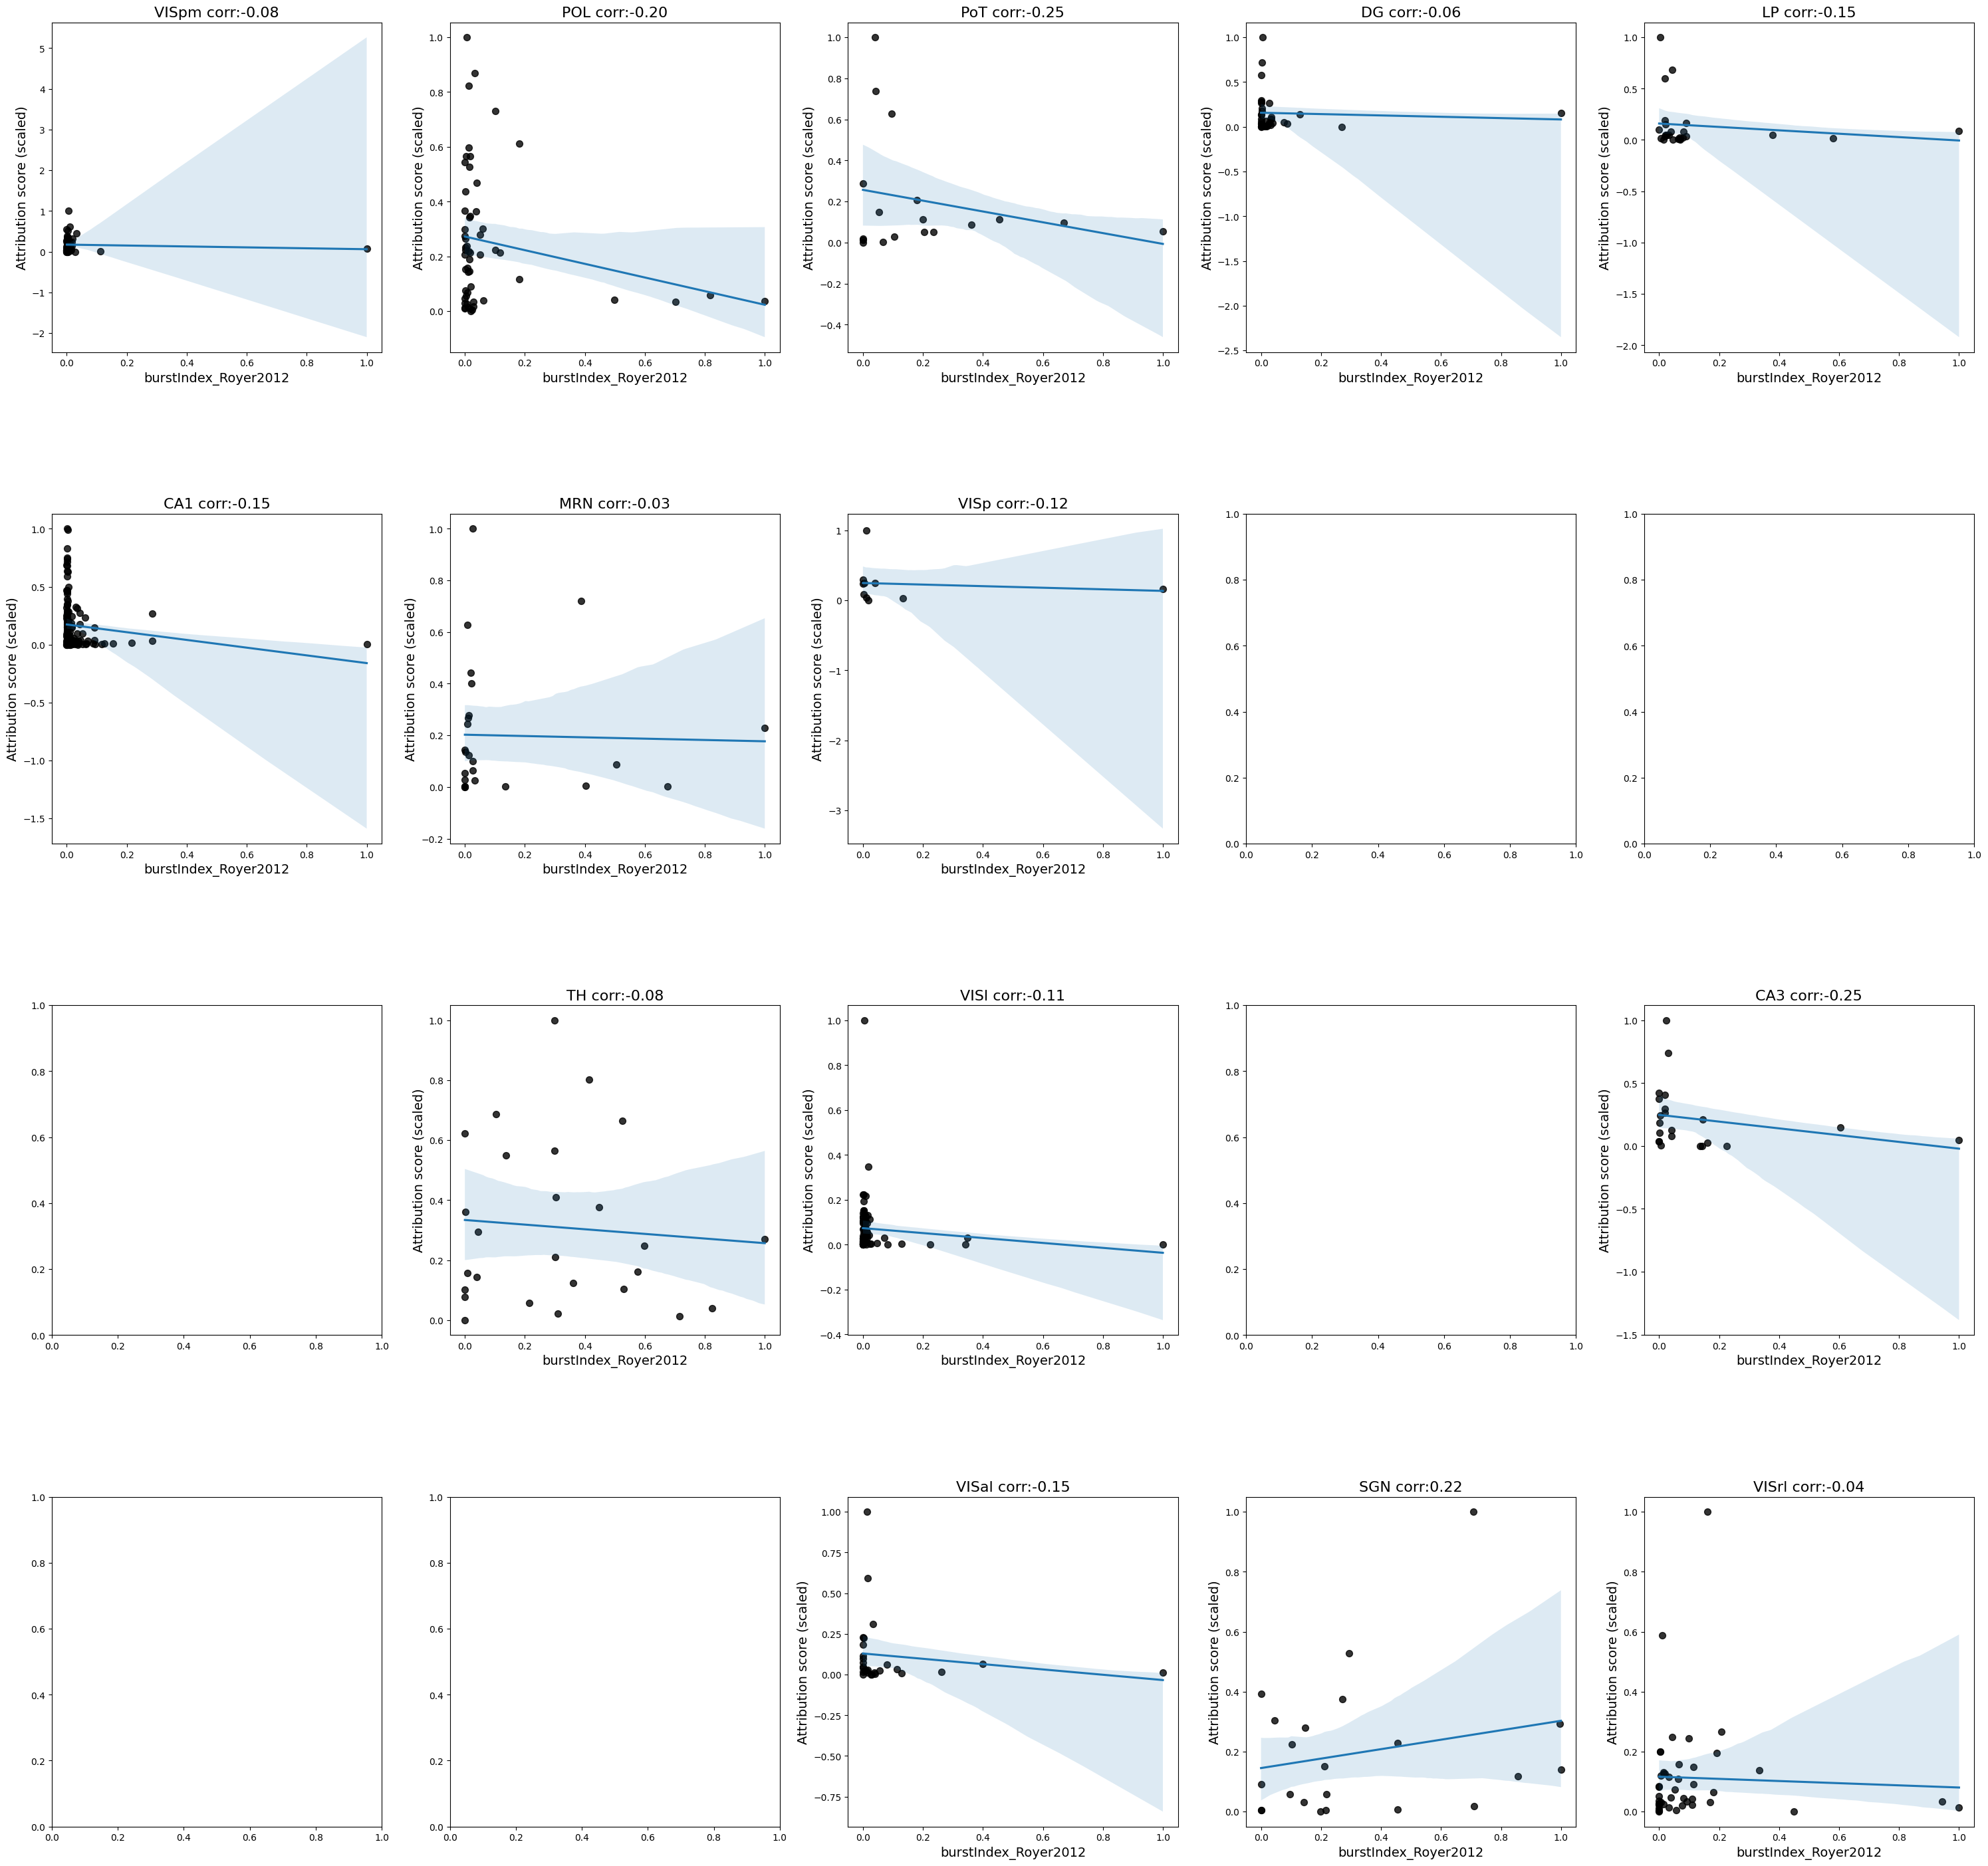

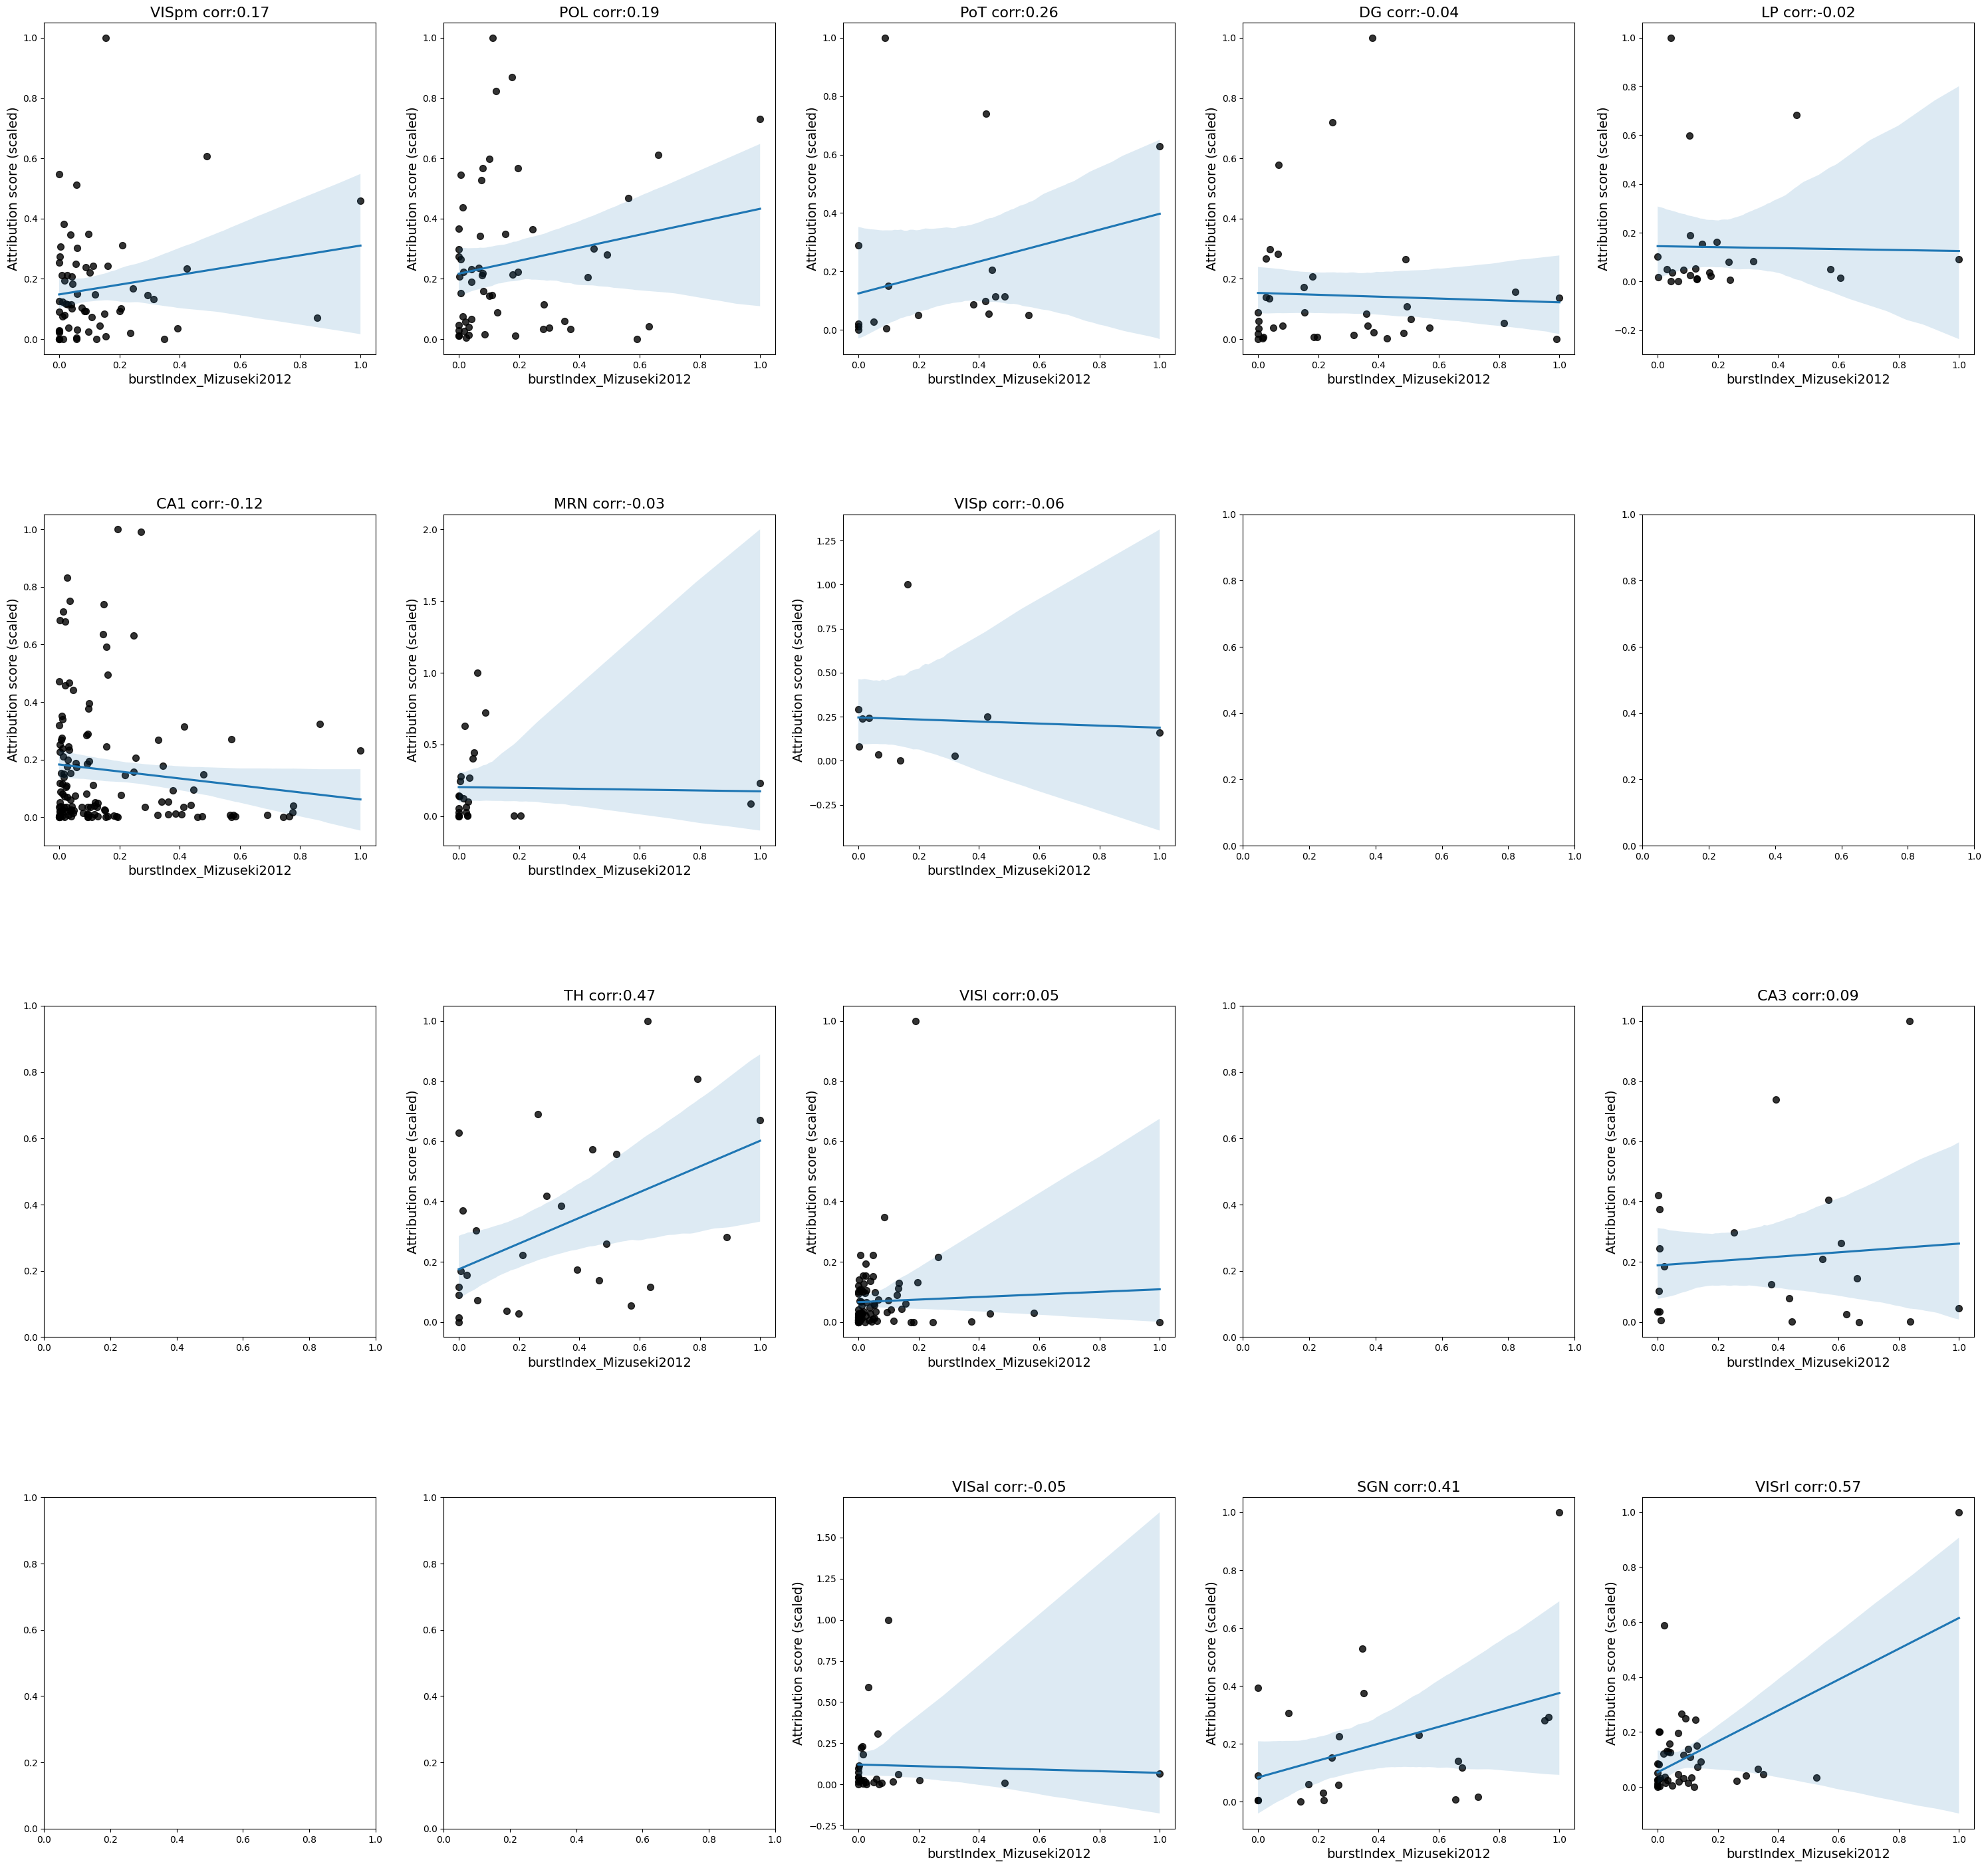

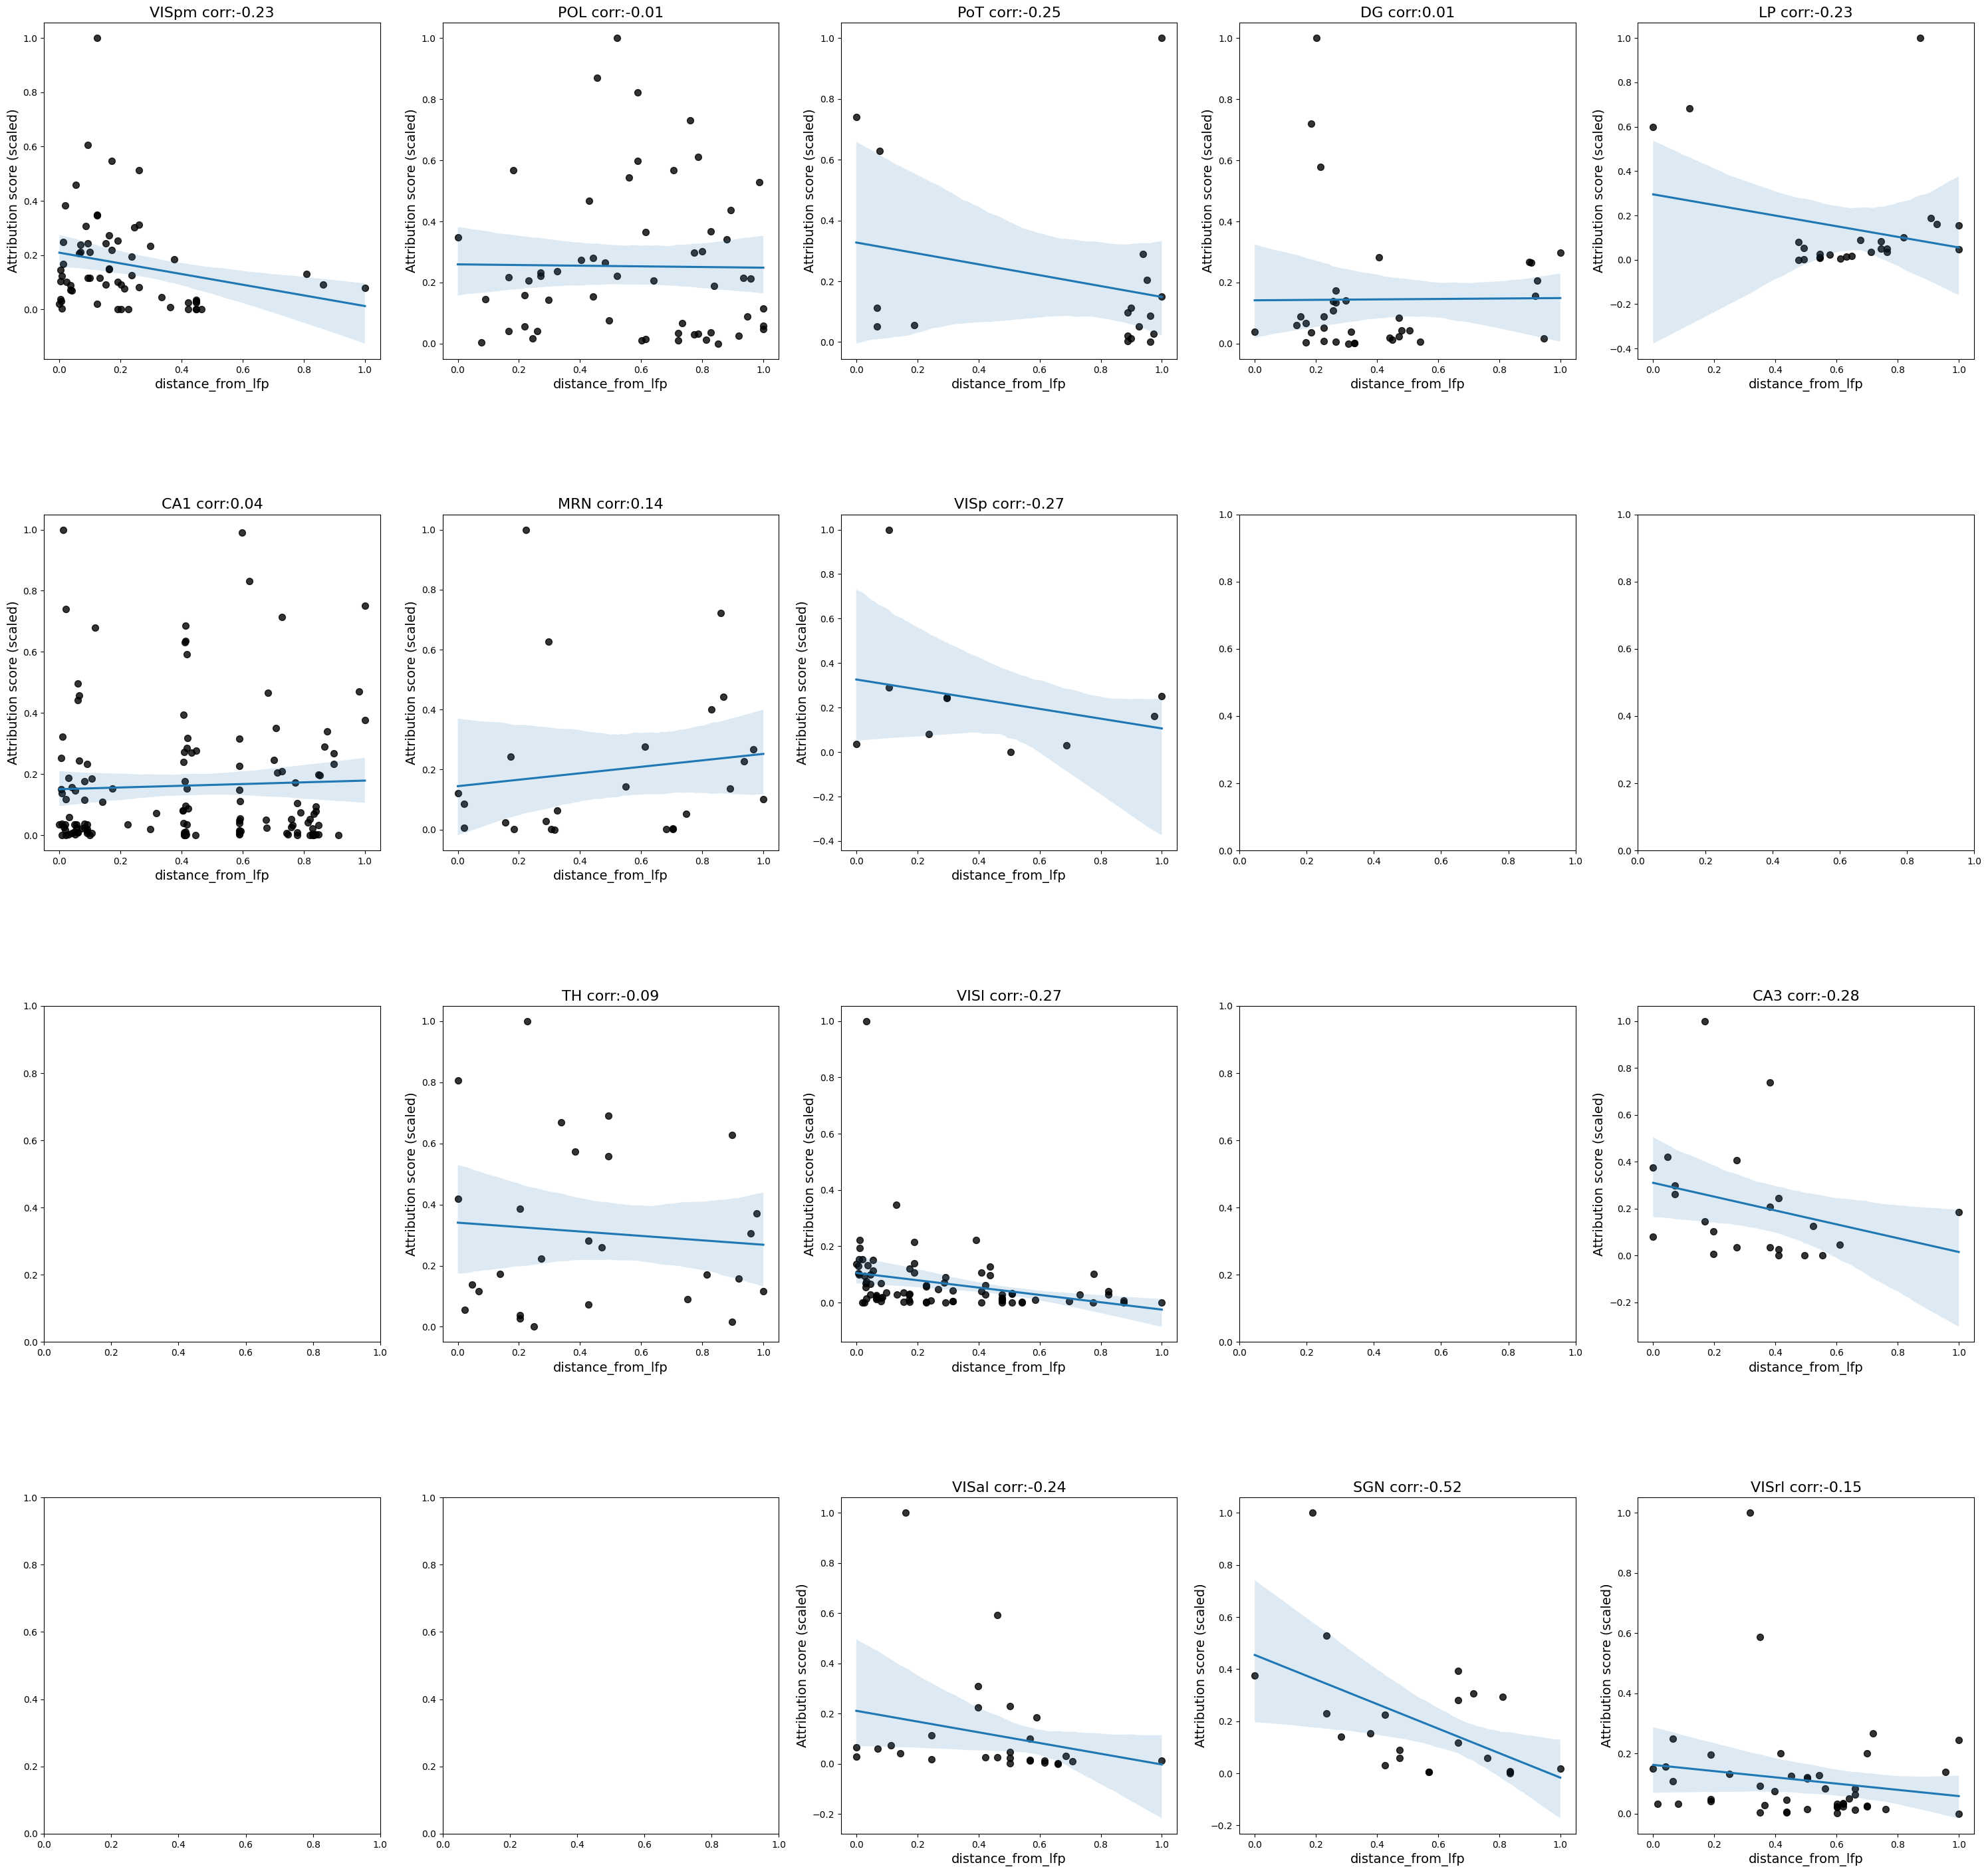

In [486]:
for metric in (metrics + ['distance_from_lfp']):
    fig, ax = plt.subplots(int(np.ceil(len(attr_df['structure_acronym'].unique())/5)), 5, figsize=(30, 30))
    for i, regi in enumerate(attr_df['structure_acronym'].unique()):
        regidx = attr_df['structure_acronym'] == regi
        # Attribution scores for this region
        attr_vals = np.mean(np.abs(attrs[:,regidx.values].cpu().numpy()), axis=0)
        # Metric values for this region
        metric_vals = attr_df[metric][regidx].values

        # Remove NaN and inf values from both arrays
        valid_mask = (~np.isnan(metric_vals)) & (~np.isinf(metric_vals)) & (~np.isnan(attr_vals)) & (~np.isinf(attr_vals))
        if np.sum(valid_mask) < 10:
            ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')
            continue  # skip if no valid data

        scaled1 = scaler.fit_transform(attr_vals[valid_mask].reshape(-1,1))
        scaled2 = scaler.fit_transform(metric_vals[valid_mask].reshape(-1,1))

        sns.regplot(x=scaled2.flatten(), y=scaled1.flatten(), ax=ax.flat[i], scatter_kws={'s': 50, 'color': 'k'})
        ax.flat[i].set_title(f'{regi} corr:{np.corrcoef(scaled2.flatten(), scaled1.flatten())[0, 1]:.2f}', fontsize=16)
        ax.flat[i].set_ylabel('Attribution score (scaled)', fontsize=14)
        ax.flat[i].set_xlabel(metric, fontsize=14)
        ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')

        # ax.flat[i].scatter(scaled2, scaled1,50, 'k', label=regi)
        # ax.flat[i].set_title(regi, fontsize=16)
        # ax.flat[i].set_ylabel('Attribution score (scaled)', fontsize=14)
        # ax.flat[i].set_xlabel(metric, fontsize=14)
        # ax.flat[i].set_aspect(1.0/ax.flat[i].get_data_ratio(), adjustable='box')
    plt.tight_layout()
    plt.show()

In [461]:
# create a new dataframe with the columns from metrics plus structure_acronym and attribution_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

encoder = OneHotEncoder(sparse_output=False)
structure_encoded = encoder.fit_transform(attr_df[['structure_acronym']])

# # train a decision tree regressor on the attribution score and the metrics
X = np.hstack([structure_encoded, attr_df[metrics + ['distance_from_lfp']].values])


In [471]:
X_train, X_test, y_train, y_test = train_test_split(X, attr_df['attribution_score'].values, test_size=0.2, random_state=42)

# Train a Random Forest Regressor with the hyperparameters from Optuna
def objective(trial):
    rf_model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 50, 200),
        max_depth=trial.suggest_int("max_depth", 5, 20),
        random_state=42,
        n_jobs=-1
    )
    
    train_data, valid_data, train_target, valid_target = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    rf_model.fit(train_data, train_target)
    y_pred = rf_model.predict(valid_data)
    return r2_score(valid_target, y_pred)

study = optuna.create_study(direction='maximize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=100)
print("Best hyperparameters: ", study.best_params)
rf_model = RandomForestRegressor(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    n_jobs=-1
)

[I 2025-05-28 17:06:13,009] A new study created in memory with name: no-name-337eaa77-ceb1-435f-9601-304ab77bcace


Best hyperparameters:  {'n_estimators': 57, 'max_depth': 16}


R^2 score of the regressor: 0.2859


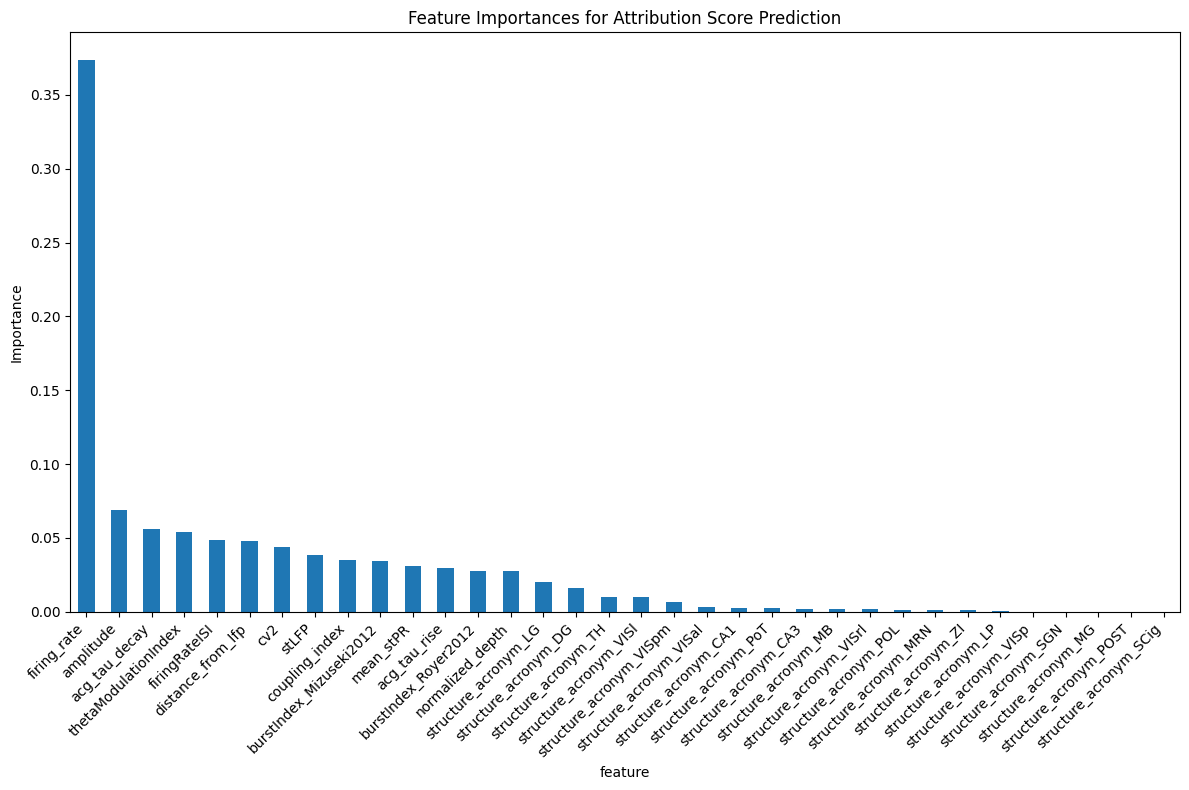

In [472]:
# regressor = DecisionTreeRegressor()
rf_model.fit(X_train, y_train)

# Evaluate the model
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2 score of the regressor: {r2:.4f}')

# Get feature importances
importances = rf_model.feature_importances_
# Create a DataFrame for feature importances
feature_names = encoder.get_feature_names_out(['structure_acronym']) \
    .tolist() + metrics + ['distance_from_lfp']
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot feature importances
fig, ax = plt.subplots(figsize=(12, 8))
importance_df.plot(kind='bar', x='feature', y='importance', ax=ax, legend=False)
ax.set_title('Feature Importances for Attribution Score Prediction')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.4509
Linear regression test loss: 3.3875


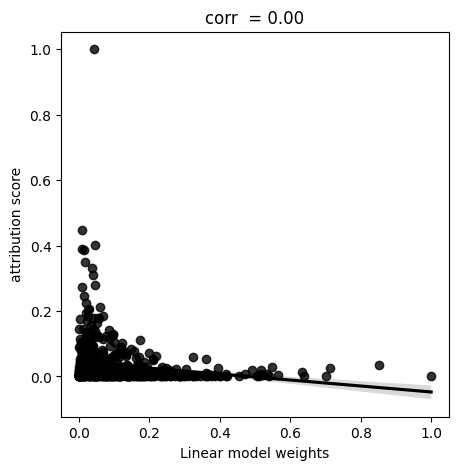

In [ ]:
# correlation between linear regression weights and transformer attribution scores
weights = linear_model.model.coef_
mean_attr_transformer = np.mean(attrs.cpu().numpy(), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=scaler.fit_transform(np.abs(weights).reshape(-1, 1)), 
            y=scaler.fit_transform(np.abs(mean_attr_transformer).reshape(-1, 1)), ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(weights, mean_attr_transformer)[0,1]:.2f}')
# ax.set_xlim([0, 0.2])
plt.show()

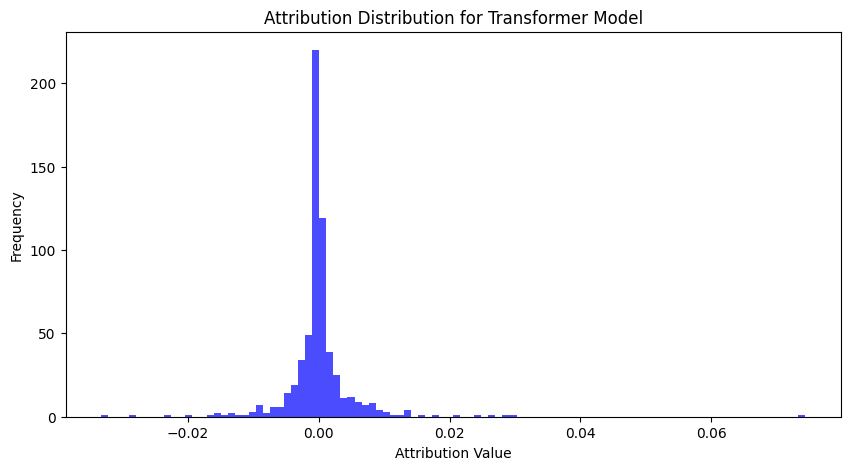

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(mean_attr_transformer, bins=100, color='blue', alpha=0.7)
ax.set_xlabel('Attribution Value')
ax.set_ylabel('Frequency')
ax.set_title('Attribution Distribution for Transformer Model')
plt.show()


In [26]:
gru_model = models.process_model(models.GRUnet(input_size, hidden_size, num_layers, seqlength=study.best_params['seqlength'], batchNorm=False), criterion, device)
gru_train_loss, gru_test_loss = gru_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'GRU  train loss: {gru_train_loss[-1]:.4f}')
print(f'GRU  test loss: {gru_test_loss[-1]:.4f}')

GRU  train loss: 0.2901
GRU  test loss: 0.3106


In [27]:
ig2 = IntegratedGradient(gru_model.model.train().to(device), method='last time point', seqlength=study.best_params['seqlength']) 
attrs2 = ig2.run(X_attr, baselines = 0, n_steps = 50)

100%|██████████| 3600/3600 [07:18<00:00,  8.21it/s]


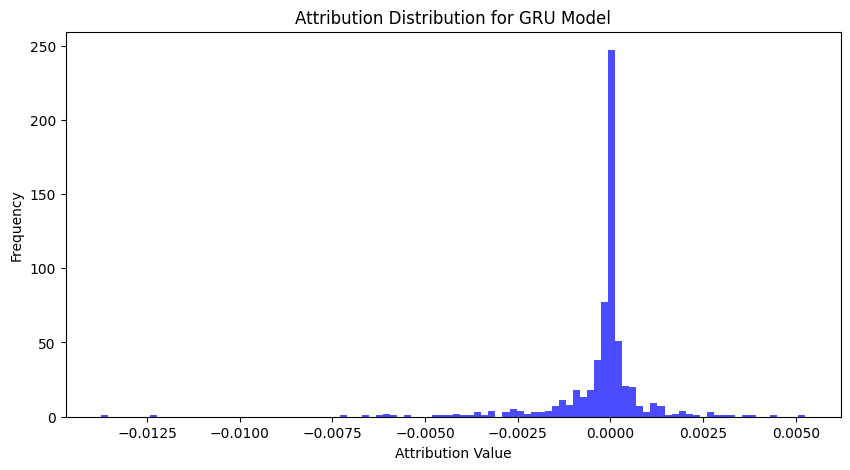

In [28]:
mean_attr_gru = np.mean(attrs2.cpu().numpy(), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(mean_attr_gru, bins=100, color='blue', alpha=0.7)
ax.set_xlabel('Attribution Value')
ax.set_ylabel('Frequency')
ax.set_title('Attribution Distribution for GRU Model')
plt.show()

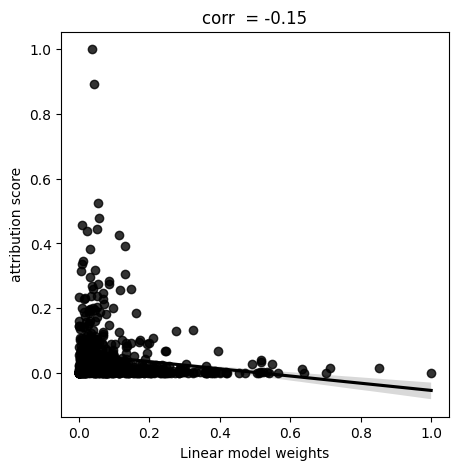

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=scaler.fit_transform(np.abs(weights).reshape(-1, 1)), 
            y=scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(  scaler.fit_transform(np.abs(weights).reshape(-1, 1)).T, scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)).T )[0,1]:.2f}')
# ax.set_xlim([0, 0.2])
plt.show()

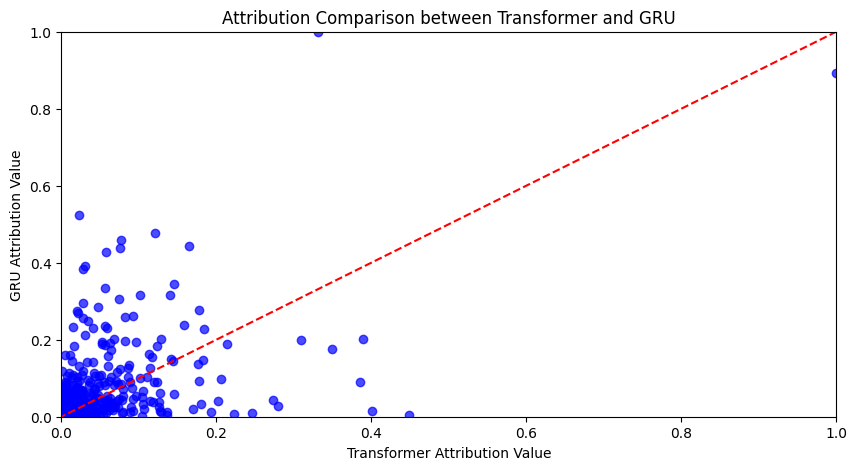

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(scaler.fit_transform(np.abs(mean_attr_transformer).reshape(-1, 1)),
           scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), color='blue', alpha=0.7)
ax.set_xlabel('Transformer Attribution Value')
ax.set_ylabel('GRU Attribution Value')
ax.set_title('Attribution Comparison between Transformer and GRU')
ax.plot([-1, 1], [-1, 1], 'r--') # Diagonal line for reference
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

In [ ]:
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.2767
LSTM  test loss: 0.3002


In [98]:
ig3 = IntegratedGradient(lstm_model.model.train().to(device), method='last time point', seqlength=seqlength)
attrs3 = ig3.run(X_attr, baselines = 0, n_steps = 50)
mean_attr_lstm = np.mean(attrs3.cpu().numpy(), axis=0)

100%|██████████| 3600/3600 [09:26<00:00,  6.36it/s]


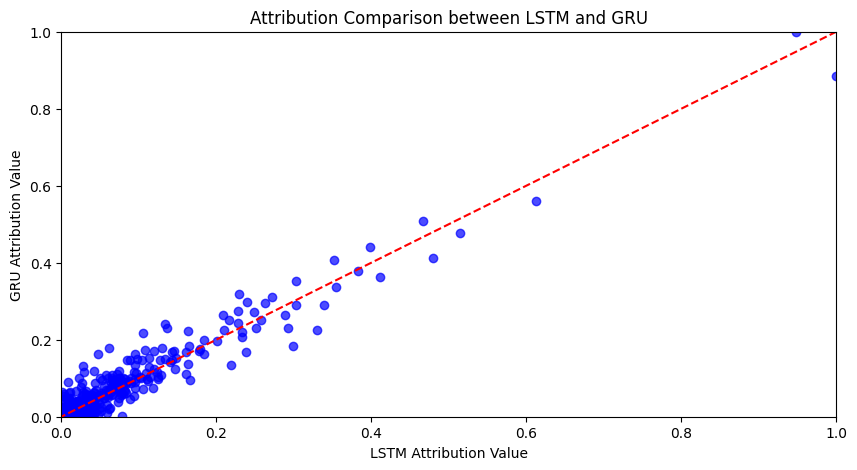

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(scaler.fit_transform(np.abs(mean_attr_lstm).reshape(-1, 1)),
           scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), color='blue', alpha=0.7)
ax.set_xlabel('LSTM Attribution Value')
ax.set_ylabel('GRU Attribution Value')
ax.set_title('Attribution Comparison between LSTM and GRU')
ax.plot([-1, 1], [-1, 1], 'r--') # Diagonal line for reference
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()